# Evolution cycle analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# OPTIONS FOR ANALYSIS
# ('algo' 'corss'/'mut' 'pop'x'gen')
#ref = '2025-06-14_17-53-11' # NSGA-II 80/10 50x50
#ref = '2025-06-14_16-36-03' # NSGA-II 80/20 50x50 # higher mut
#ref = '2025-06-14_22-45-37' # NSGA-II 80/5 50x50 # lower mut
#ref = '2025-06-14_23-37-07' # NSGA-II 80/10 25x50 # lower pop
ref = '2025-06-15_12-48-46' # NSGA-II 80/10 100x50 # higher pop
#ref = '2025-06-14_14-33-43' # NSGA-II 80/10 50x100 # higher gen

algo = 'NSGA-II'
filename = f'{algo}_{ref}'

history_file = f'history/evolution_{filename}'
results_file = f'results/results_{filename}'

In [3]:
df = pd.read_csv(f"{history_file}.csv")
try:
    df_res = pd.read_csv(f"{results_file}.csv")
    Finished = True
except:
    df_res = None
    Finished = False

In [4]:
if Finished: df['best'] = df['fitness'].isin(df_res['fitness'])

In [5]:
df.head()

,params,file_size,peaq_score,distortion_index,processing_time,fitness,best
0,"{'ar': '24000', 'sample_fmt': 'fltp', 'compres...",186.195312,-3.662,-2.501,0.749544,-0.758538,False
1,"{'ar': '32000', 'sample_fmt': 's32p', 'compres...",396.640625,-3.173,-1.435,0.706733,0.384444,False
2,"{'ar': '22050', 'sample_fmt': 'fltp', 'compres...",75.088867,-3.731,-2.763,0.406703,-0.799325,False
3,"{'ar': '24000', 'sample_fmt': 's16p', 'compres...",223.671875,-3.661,-2.498,0.444020,-0.792480,False
4,"{'ar': '11025', 'sample_fmt': 'fltp', 'compres...",90.893555,-3.849,-3.437,0.341019,-1.307241,False


In [6]:
if Finished: df_res.head()

In [7]:
# Define your weights
# weights = {
#     'file_size': -0.5,
#     'peaq_score': 1,
#     'distortion_index': 0.3,
#     'processing_time': -0.05
#}

In [8]:
# Calculate the weighted fitness for each row
# df['fitness'] = (
#     df['file_size'] * weights['file_size'] +
#     df['peaq_score'] * weights['peaq_score'] +
#     df['distortion_index'] * weights['distortion_index'] +
#     df['processing_time'] * weights['processing_time']
# )

In [9]:
df.head()

,params,file_size,peaq_score,distortion_index,processing_time,fitness,best
0,"{'ar': '24000', 'sample_fmt': 'fltp', 'compres...",186.195312,-3.662,-2.501,0.749544,-0.758538,False
1,"{'ar': '32000', 'sample_fmt': 's32p', 'compres...",396.640625,-3.173,-1.435,0.706733,0.384444,False
2,"{'ar': '22050', 'sample_fmt': 'fltp', 'compres...",75.088867,-3.731,-2.763,0.406703,-0.799325,False
3,"{'ar': '24000', 'sample_fmt': 's16p', 'compres...",223.671875,-3.661,-2.498,0.444020,-0.792480,False
4,"{'ar': '11025', 'sample_fmt': 'fltp', 'compres...",90.893555,-3.849,-3.437,0.341019,-1.307241,False


In [10]:
df.describe()

,file_size,peaq_score,distortion_index,processing_time,fitness
count,4590.000000,4590.000000,4590.000000,4590.000000,4590.000000
mean,218.722095,-3.231081,-1.735896,0.606226,0.445526
std,157.619305,0.411506,0.847138,0.184157,1.074942
min,35.867188,-3.858000,-3.512000,0.334987,-1.376786
25%,54.300781,-3.632750,-2.407750,0.482085,-0.545054
50%,179.515625,-3.174000,-1.438000,0.575496,0.314096
75%,356.811523,-2.942000,-1.113000,0.676252,1.386241
max,447.265625,-2.581000,-0.694000,2.208180,2.128162


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4590 entries, 0 to 4589
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   params            4590 non-null   object 
 1   file_size         4590 non-null   float64
 2   peaq_score        4590 non-null   float64
 3   distortion_index  4590 non-null   float64
 4   processing_time   4590 non-null   float64
 5   fitness           4590 non-null   float64
 6   best              4590 non-null   bool   
dtypes: bool(1), float64(5), object(1)
memory usage: 219.8+ KB


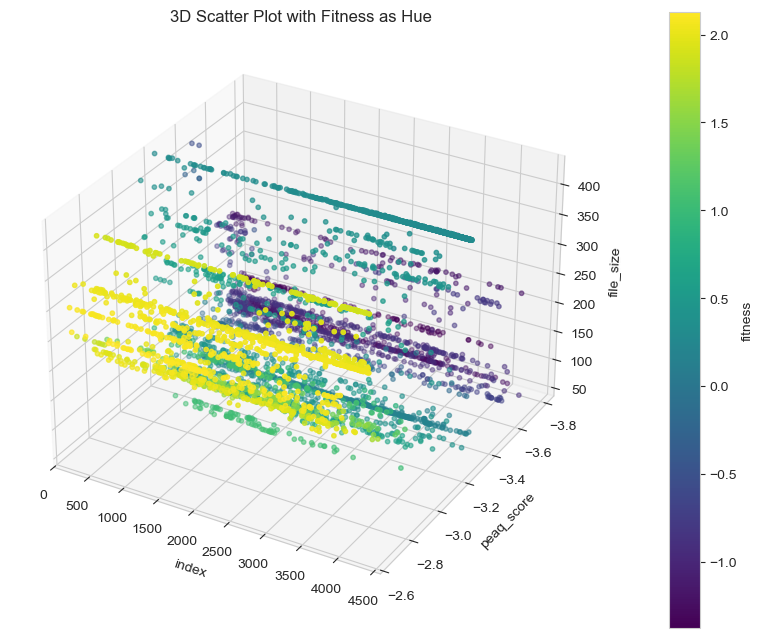

In [12]:
num_points = len(df)

# Set seaborn style for better aesthetics
sns.set_style("whitegrid")

# Create a 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D scatter plot with 'fitness' determining the color
# 'c' parameter is used to map numerical values to colors, and 'cmap' specifies the colormap
scatter = ax.scatter(
    df.index,         # X-axis
    df['peaq_score'], # Y-axis
    df['file_size'],  # Z-axis (using dfFrame index as requested)
    c=df['fitness'],  # Color based on 'fitness' values
    cmap='viridis',   # Colormap (you can try others like 'plasma', 'magma', 'cividis')
    s=10              # Size of the scatter points
)

# Set labels for each axis
ax.set_xlabel('index')
ax.set_ylabel('peaq_score')
ax.set_zlabel('file_size')

# Set the limits for each axis
ax.set_xlim(0, num_points) # Z-axis limit set to the number of df points
ax.set_ylim(df['peaq_score'].max(), df['peaq_score'].min())
ax.set_zlim(df['file_size'].min(), df['file_size'].max())

# Set the title of the plot
ax.set_title('3D Scatter Plot with Fitness as Hue')

# Add a color bar to explain the 'fitness' color mapping
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('fitness')

# Display the plot
plt.show()

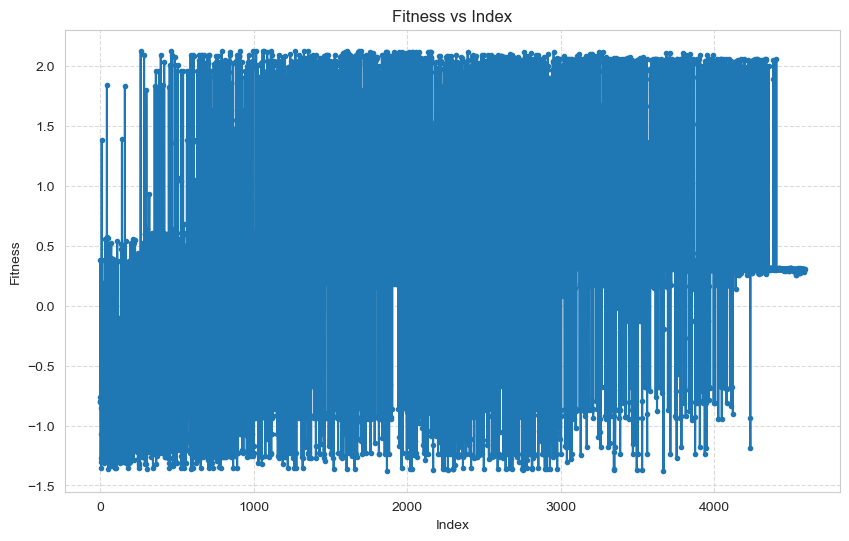

In [13]:
data = df.reset_index()
plt.figure(figsize=(10, 6))
plt.plot(data['index'], data['fitness'], marker='o', linestyle='-', markersize=3)
plt.xlabel('Index')
plt.ylabel('Fitness')
plt.title('Fitness vs Index')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [14]:
total_individuals = len(df)
total_individuals

4590

In [15]:
portion = 0.5
num_sample = int(total_individuals * portion)
num_sample

2295

In [16]:
data_full = df
data_full = data_full.reset_index()
data = data_full.sample(num_sample)

In [17]:
data = data.sort_values(by='index')

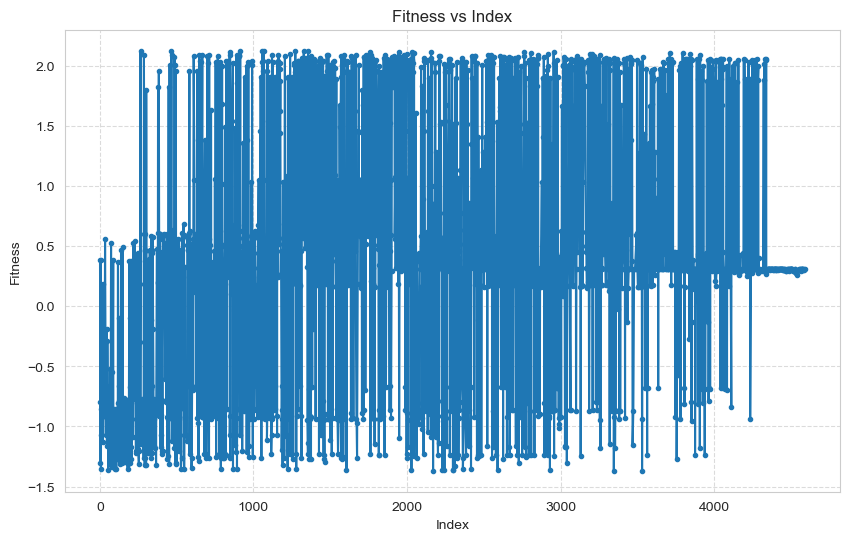

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(data['index'], data['fitness'], marker='o', linestyle='-', markersize=3)
plt.xlabel('Index')
plt.ylabel('Fitness')
plt.title('Fitness vs Index')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [19]:
convergence_target = 2

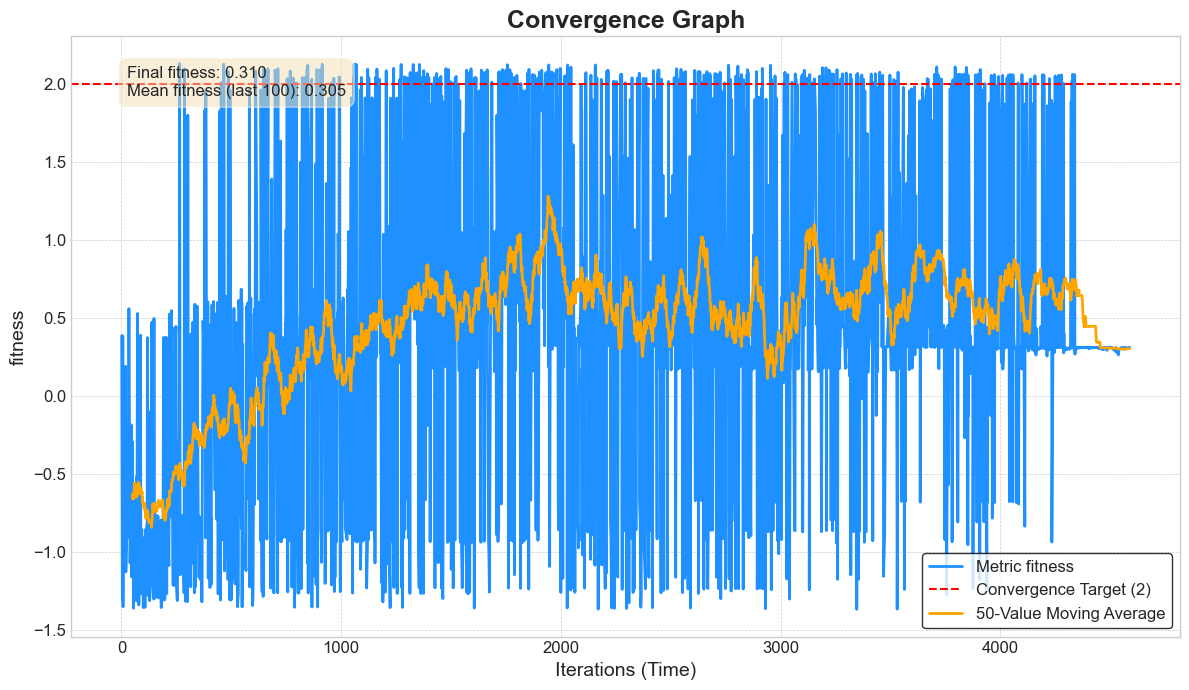

In [20]:
# --- Create the Convergence Graph ---

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the convergence data
ax.plot(data['index'], data['fitness'], label='Metric fitness', color='dodgerblue', linewidth=2)

# Add a horizontal line for the convergence target
ax.axhline(y=convergence_target, color='r', linestyle='--', label=f'Convergence Target ({convergence_target})')

# Calculate the 50-value moving average
data_full['moving_average_50'] = data_full['fitness'].rolling(window=50).mean()

# Plot the 50-value moving average
ax.plot(data_full['index'], data_full['moving_average_50'], label='50-Value Moving Average', color='orange', linewidth=2)

# Customize the plot
ax.set_title('Convergence Graph', fontsize=18, fontweight='bold')
ax.set_xlabel('Iterations (Time)', fontsize=14)
ax.set_ylabel('fitness', fontsize=14)
ax.legend(fontsize=12, frameon=True, facecolor='white', edgecolor='black') 
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add a text box with some stats
stats_text = (f"Final fitness: {data['fitness'].iloc[-1]:.3f}\n"
            f"Mean fitness (last 100): {data['fitness'].tail(100).mean():.3f}")
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


# Show the plot
plt.tight_layout()
plt.show()


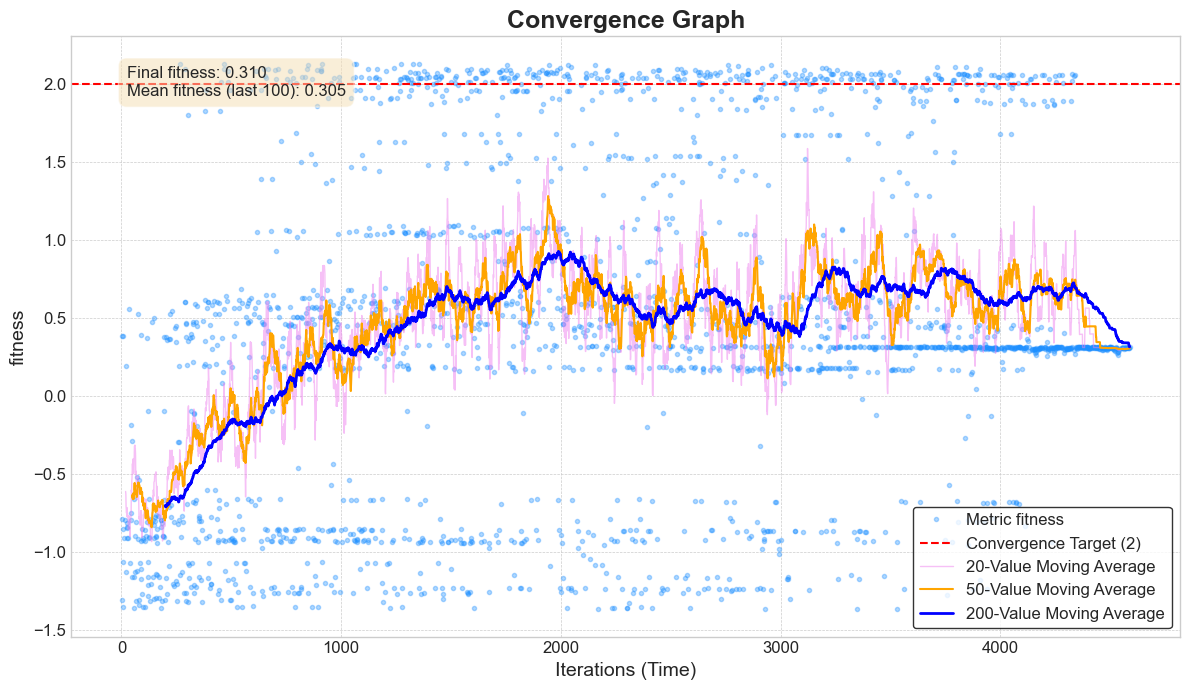

In [21]:
# --- Create the Convergence Graph ---

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the convergence data
ax.plot(data['index'], data['fitness'], label='Metric fitness', color='dodgerblue', marker='.', linestyle='', linewidth=0, alpha=0.35)

# Add a horizontal line for the convergence target
ax.axhline(y=convergence_target, color='r', linestyle='--', label=f'Convergence Target ({convergence_target})')

# Calculate the 10-value moving average
data_full['moving_average_20'] = data_full['fitness'].rolling(window=20).mean()
# Calculate the 50-value moving average
data_full['moving_average_50'] = data_full['fitness'].rolling(window=50).mean()
# Calculate the 100-value moving average
data_full['moving_average_200'] = data_full['fitness'].rolling(window=200).mean()

# Plot moving averages
ax.plot(data_full['index'], data_full['moving_average_20'], label='20-Value Moving Average', color='violet', linewidth=1, alpha=0.5)
ax.plot(data_full['index'], data_full['moving_average_50'], label='50-Value Moving Average', color='orange', linewidth=1.5)
ax.plot(data_full['index'], data_full['moving_average_200'], label='200-Value Moving Average', color='blue', linewidth=2)

# Customize the plot
ax.set_title('Convergence Graph', fontsize=18, fontweight='bold')
ax.set_xlabel('Iterations (Time)', fontsize=14)
ax.set_ylabel('fitness', fontsize=14)
ax.legend(fontsize=12, frameon=True, facecolor='white', edgecolor='black') 
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add a text box with some stats
stats_text = (f"Final fitness: {data['fitness'].iloc[-1]:.3f}\n"
            f"Mean fitness (last 100): {data['fitness'].tail(100).mean():.3f}")
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


# Show the plot
plt.tight_layout()
plt.show()


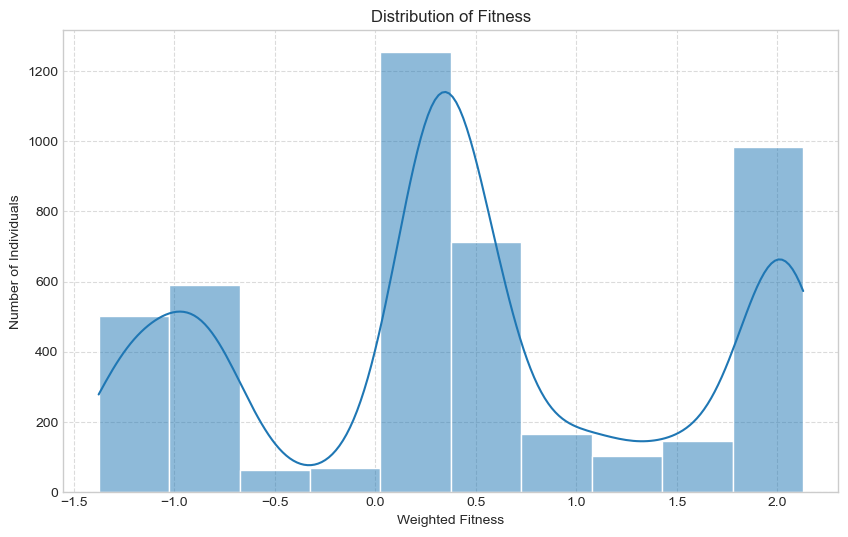

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(df['fitness'], kde=True, bins=10)
plt.title('Distribution of Fitness')
plt.xlabel('Weighted Fitness')
plt.ylabel('Number of Individuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

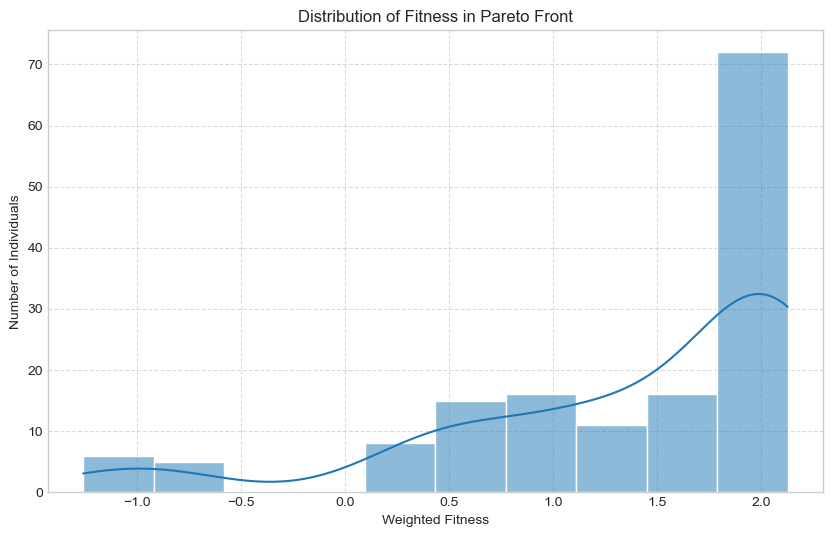

In [23]:
if Finished: 
    plt.figure(figsize=(10, 6))
    sns.histplot(df_res['fitness'], kde=True, bins=10)
    plt.title('Distribution of Fitness in Pareto Front')
    plt.xlabel('Weighted Fitness')
    plt.ylabel('Number of Individuals')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# History

peaq_score


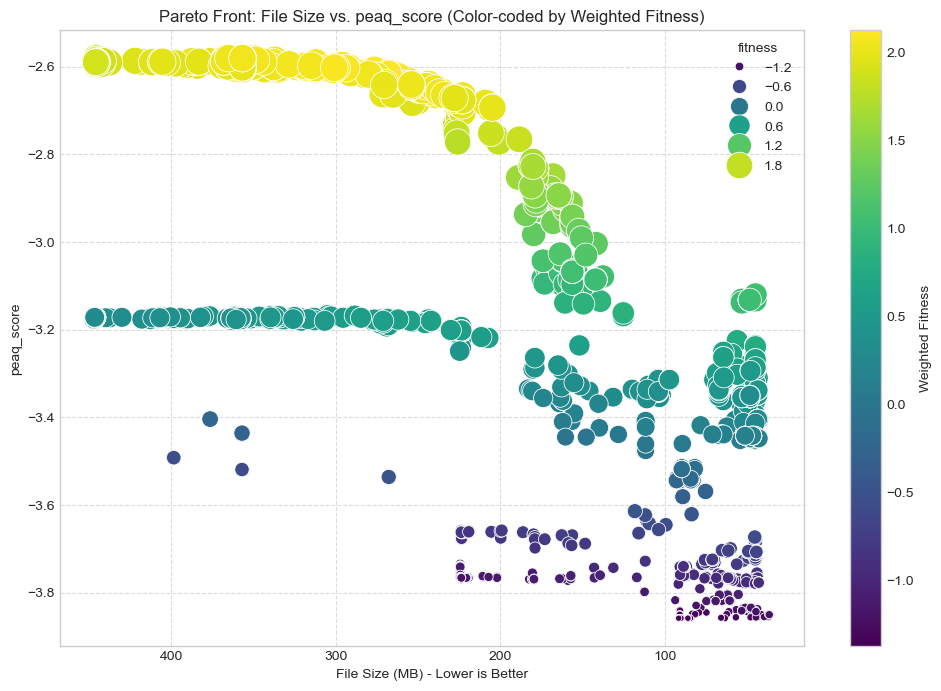

distortion_index


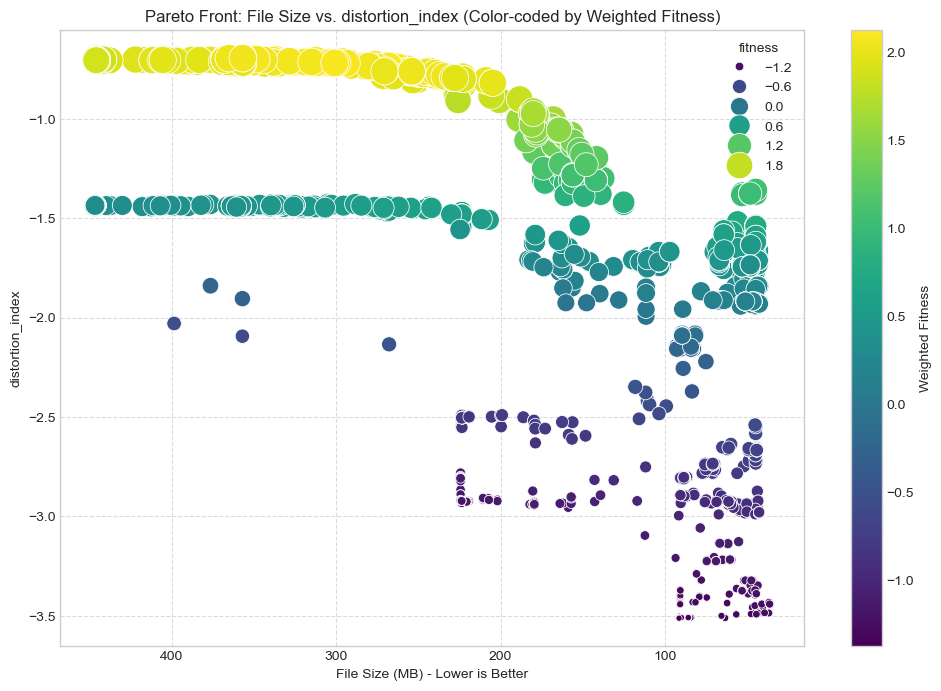

processing_time


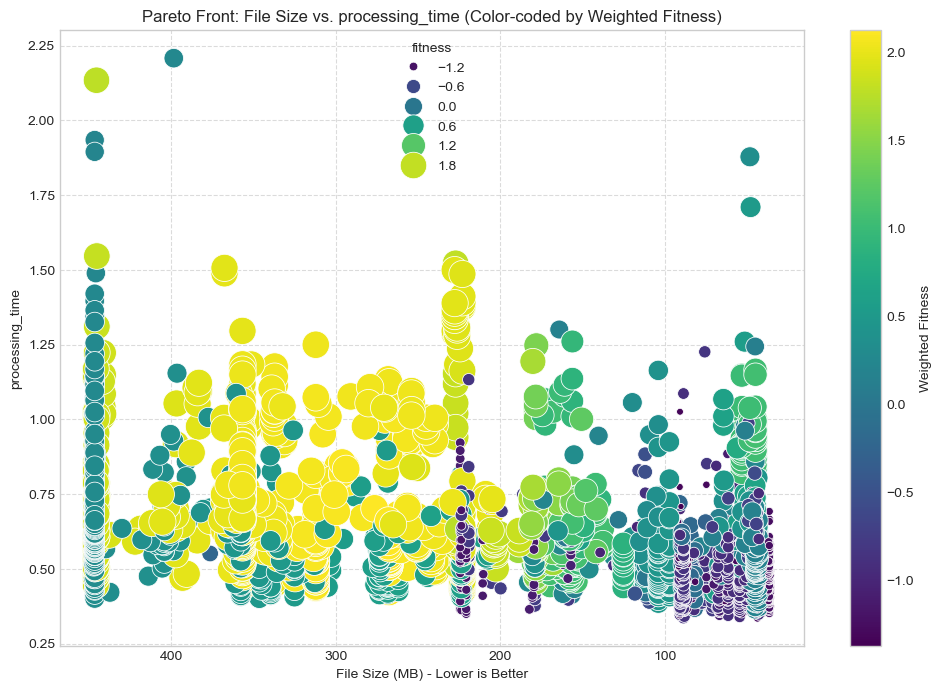

In [24]:
data = df
data = data.reset_index()

for feature in ['peaq_score','distortion_index','processing_time']:
    print(feature)
    plt.figure(figsize=(12, 8))
    scatter = sns.scatterplot(
        data=data,
        x='file_size', 
        y=feature,
        hue='fitness', # Color points by weighted fitness
        size='fitness', # Size points by weighted fitness (optional, can be removed)
        sizes=(20, 400), # Adjust size range
        palette='viridis', # Choose a colormap
        #legend='full'
    )

    # Reverse x-axis if minimizing file_size makes lower values better
    plt.gca().invert_xaxis() # Assuming lower file_size is better

    plt.title(f'Pareto Front: File Size vs. {feature} (Color-coded by Weighted Fitness)')
    plt.xlabel('File Size (MB) - Lower is Better')
    plt.ylabel(f'{feature}')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add a color bar
    norm = plt.Normalize(df['fitness'].min(), df['fitness'].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=scatter.axes)
    cbar.set_label('Weighted Fitness')

    plt.show()

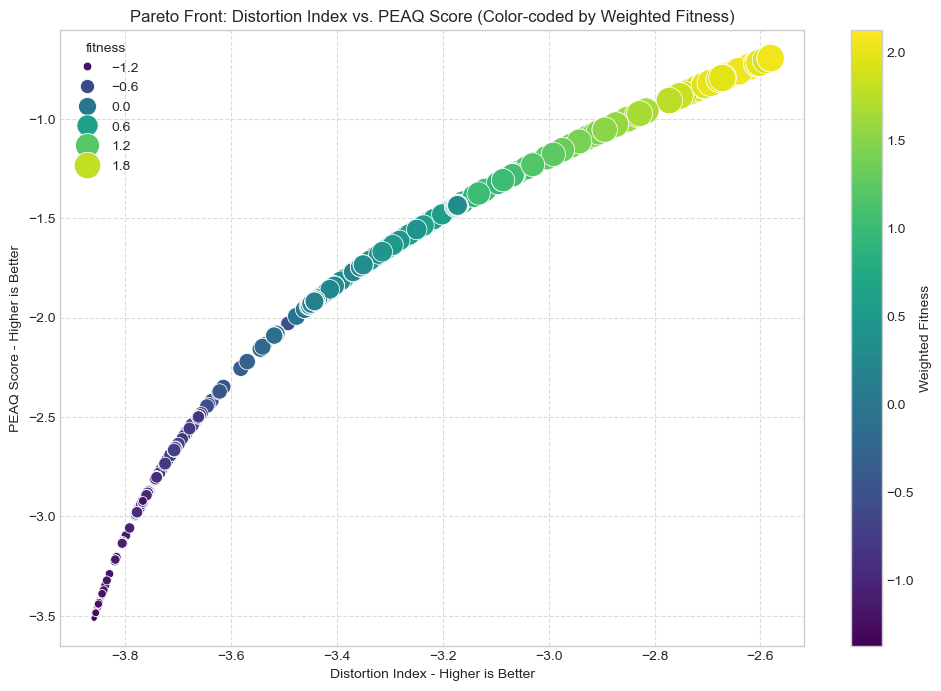

In [25]:
# ['file_size', 'peaq_score','distortion_index','processing_time']
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df,
    x='peaq_score',
    y='distortion_index',
    hue='fitness', # Color points by weighted fitness
    size='fitness', # Size points by weighted fitness (optional, can be removed)
    sizes=(20, 400), # Adjust size range
    palette='viridis', # Choose a colormap
    #legend='full'
)

# Adjust y-axis if PEAQ score's interpretation implies higher is better
# PEAQ scores are typically negative, closer to 0 or positive is better
# So, no inversion needed, higher up on the y-axis is better.

plt.title('Pareto Front: Distortion Index vs. PEAQ Score (Color-coded by Weighted Fitness)')
plt.xlabel('Distortion Index - Higher is Better')
plt.ylabel('PEAQ Score - Higher is Better')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a color bar
norm = plt.Normalize(df['fitness'].min(), df['fitness'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label('Weighted Fitness')

plt.show()

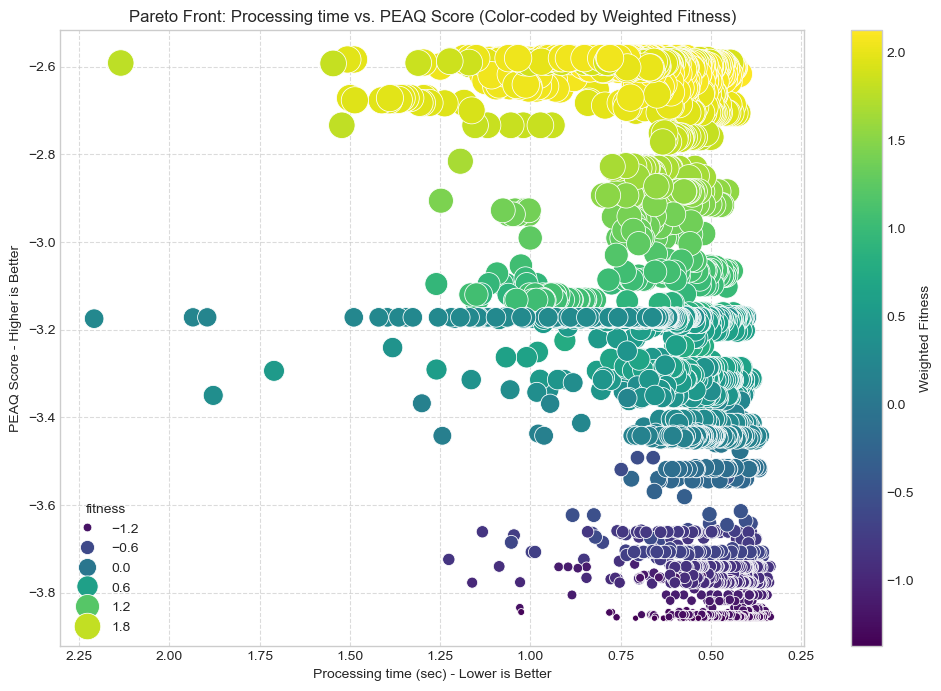

In [26]:
# ['file_size', 'peaq_score','distortion_index','processing_time']
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df,
    x='processing_time',
    y='peaq_score',
    hue='fitness', # Color points by weighted fitness
    size='fitness', # Size points by weighted fitness (optional, can be removed)
    sizes=(20, 400), # Adjust size range
    palette='viridis', # Choose a colormap
    #legend='full'
)

# Reverse x-axis if minimizing file_size makes lower values better
plt.gca().invert_xaxis() # Assuming lower file_size is better

plt.title('Pareto Front: Processing time vs. PEAQ Score (Color-coded by Weighted Fitness)')
plt.xlabel('Processing time (sec) - Lower is Better')
plt.ylabel('PEAQ Score - Higher is Better')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a color bar
norm = plt.Normalize(df['fitness'].min(), df['fitness'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label('Weighted Fitness')

plt.show()

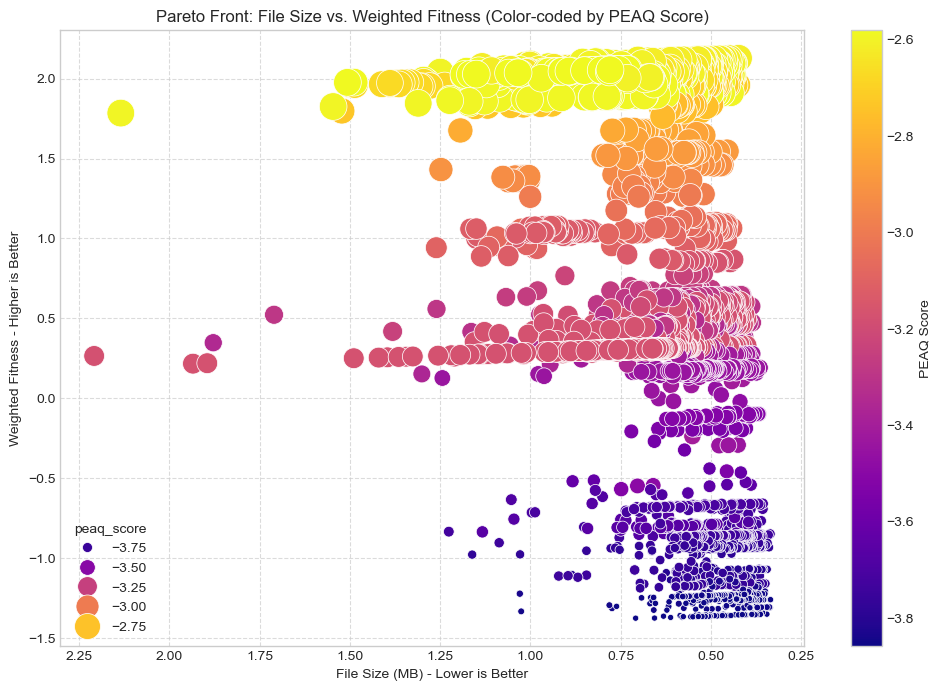

In [27]:
# ['file_size', 'peaq_score','distortion_index','processing_time']
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df,
    x='processing_time',
    y='fitness',
    hue='peaq_score', # Color points by weighted fitness
    size='peaq_score', # Size points by weighted fitness (optional, can be removed)
    sizes=(20, 400), # Adjust size range
    palette='plasma', # Choose a colormap
    #legend='full'
)

# Reverse x-axis if minimizing file_size makes lower values better
plt.gca().invert_xaxis() # Assuming lower file_size is better

# Adjust y-axis if PEAQ score's interpretation implies higher is better
# PEAQ scores are typically negative, closer to 0 or positive is better
# So, no inversion needed, higher up on the y-axis is better.

plt.title('Pareto Front: File Size vs. Weighted Fitness (Color-coded by PEAQ Score)')
plt.xlabel('File Size (MB) - Lower is Better')
plt.ylabel('Weighted Fitness - Higher is Better')
plt.grid(True, linestyle='--', alpha=0.7)

norm = plt.Normalize(df['peaq_score'].min(), df['peaq_score'].max())
sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label('PEAQ Score')

plt.show()

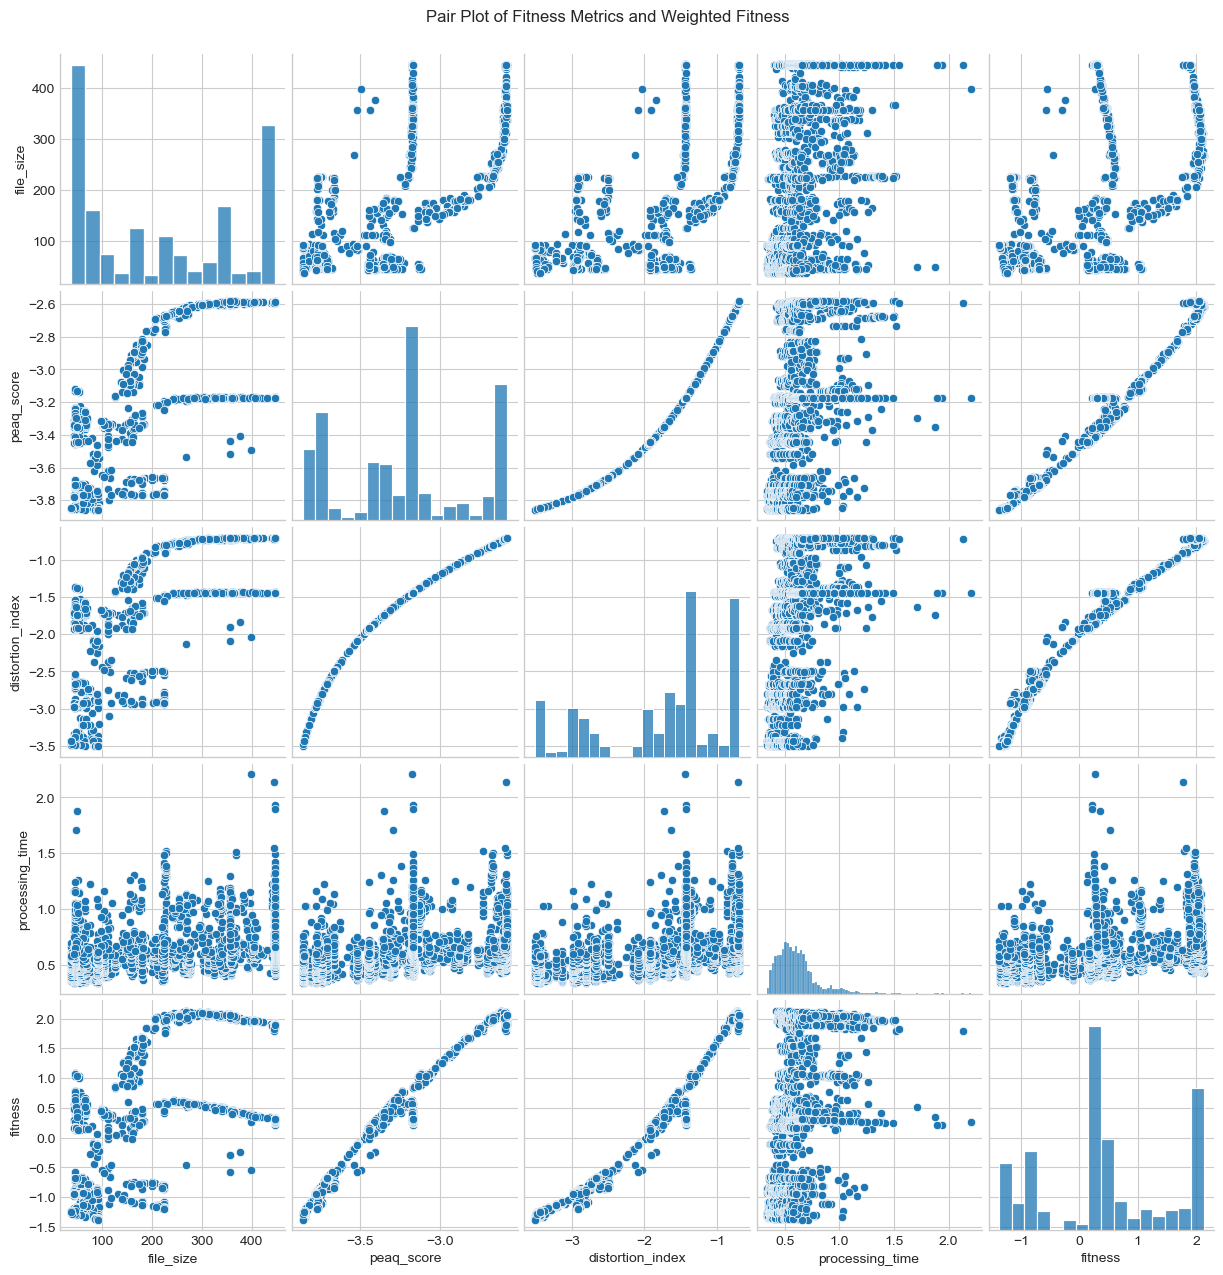

In [28]:
# Select only the numerical fitness columns and fitness for the pair plot
fitness_cols = ['file_size', 'peaq_score', 'distortion_index', 'processing_time', 'fitness']
sns.pairplot(df[fitness_cols])
plt.suptitle('Pair Plot of Fitness Metrics and Weighted Fitness', y=1.02) # Adjust title position
plt.show()

# Results

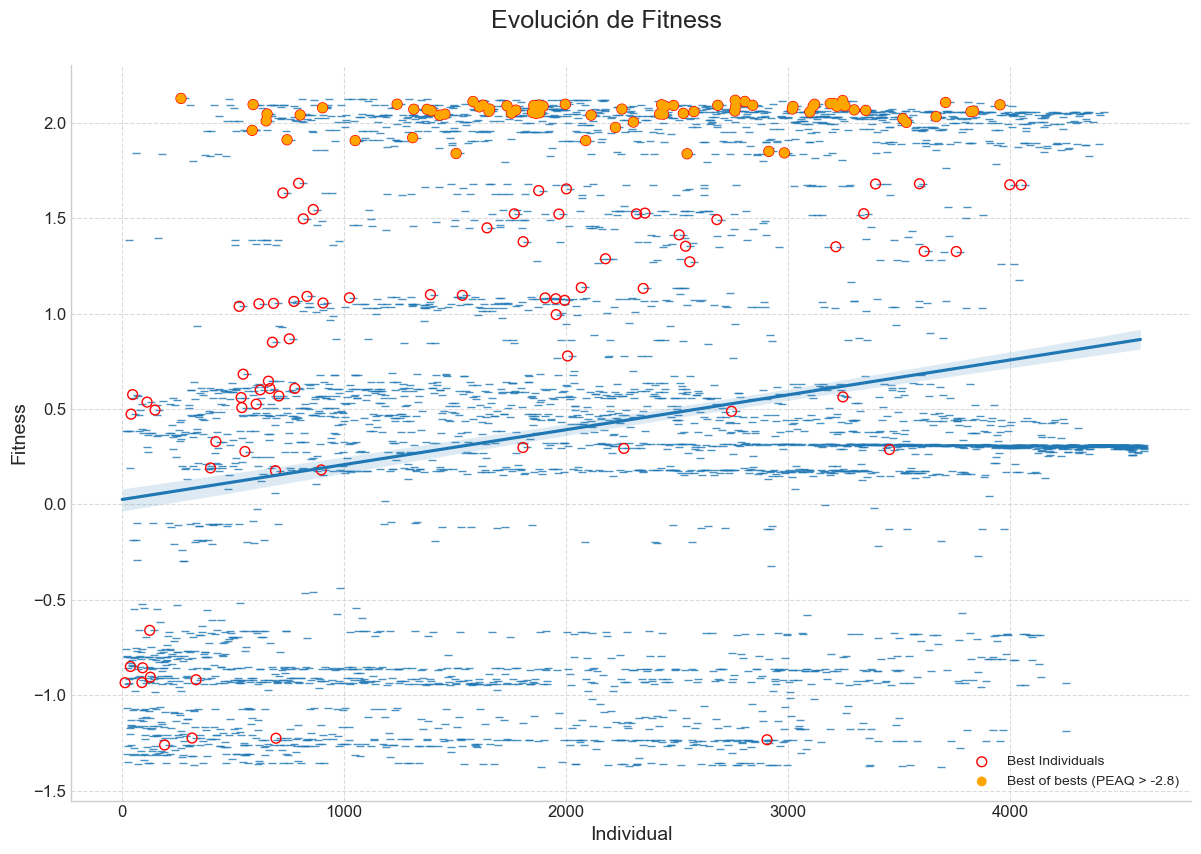

In [29]:
data = df
data = data.reset_index()

# Plot the lmplot
g = sns.lmplot(
    data=data,
    x='index',
    y="fitness",
    markers=True,
    height=8,
    aspect=1.5,
)

g.set_axis_labels("Individual", "Fitness", fontsize=14)
g.fig.suptitle("Evolución de Fitness", fontsize=18, y=1.05)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

if Finished: 
    # Overlay red circle markers for 'best' individuals
    best_points = data[data['best']]
    plt.scatter(
        best_points['index'],
        best_points['fitness'],
        facecolors='none',
        edgecolors='red',
        marker='o',
        s=50, # Increased size for better visibility
        label='Best Individuals'
    )

    # Overlay green circle markers for 'best' individuals with peaq_score > -3
    peaq_threshold = -2.8
    best_points_green = data[(data['best']) & (data['peaq_score'] > peaq_threshold)]
    plt.scatter(
        best_points_green['index'],
        best_points_green['fitness'],
        facecolors='orange',
        edgecolors='none',
        marker='o',
        s=50, # Increased size for better visibility
        label=f'Best of bests (PEAQ > {peaq_threshold})'
    )

plt.legend(loc='lower right') # Moved legend to avoid conflict with annotation

plt.show()

In [30]:
from scipy import stats

# Calculate the slope and intercept using scipy.stats.linregress
slope, intercept, r_value, p_value, std_err = stats.linregress(data['index'], data['fitness'])

# Calcular el valor 'y' para len(df)
y_final = slope * len(df) + intercept

def improves(initial, final):
    if initial == 0: return '∞' #float('inf')
    improvement = abs(final/initial)
    if round(improvement) < 1:
        return f'{round(improvement,2)}x'
    else:
        return f'{round(improvement)}x'

print(f"Pendiente de la curva de tendencia: {slope:.4f}")
print(f"Coeficiente de correlación (R): {r_value:.4f}\n")
print(f"Fitness medio incial: {intercept:.4f}")
print(f"Fitness medio final: {y_final:.4f}")
print(f'Representa una mejora de {improves(intercept,y_final)}')

Pendiente de la curva de tendencia: 0.0002
Coeficiente de correlación (R): 0.2253

Fitness medio incial: 0.0262
Fitness medio final: 0.8650
Representa una mejora de 33x


---

In [31]:
if not Finished:
    raise RuntimeError("Execution stopped: Results file not found or process not finished.")

In [32]:
data = df_res
data = data.reset_index()

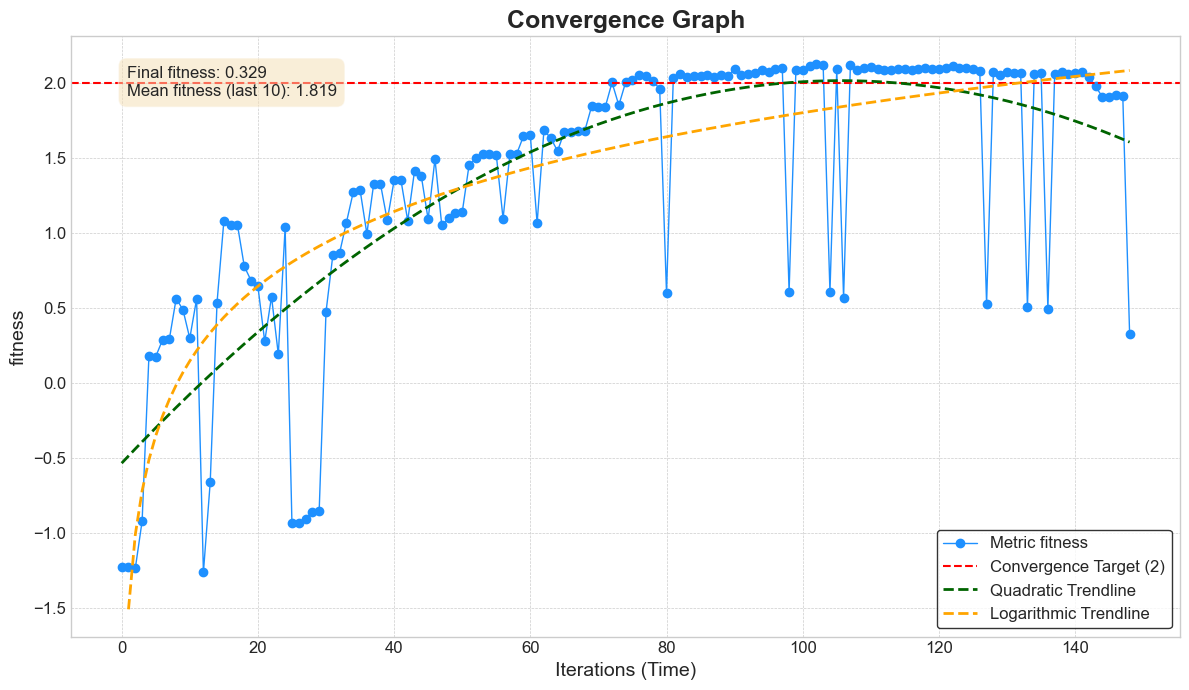

In [33]:
# --- Create the Convergence Graph ---

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the convergence data
ax.plot(data['index'], data['fitness'], label='Metric fitness', color='dodgerblue', marker='o', linestyle='-', linewidth=1, alpha=1)

# Add a horizontal line for the convergence target
ax.axhline(y=convergence_target, color='r', linestyle='--', label=f'Convergence Target ({convergence_target})')

# # Calculate the 10-value moving average
# data['moving_average_10'] = data['fitness'].rolling(window=10).mean()
# # Calculate the 50-value moving average
# data['moving_average_50'] = data['fitness'].rolling(window=50).mean()
# # Calculate the 100-value moving average
# data['moving_average_200'] = data['fitness'].rolling(window=200).mean()

# Plot moving averages
# ax.plot(data['index'], data['moving_average_10'], label='10-Value Moving Average', color='violet', linewidth=2, alpha=0.5)
# ax.plot(data['index'], data['moving_average_50'], label='50-Value Moving Average', color='orange', linewidth=2)
# ax.plot(data['index'], data['moving_average_200'], label='200-Value Moving Average', color='blue', linewidth=2)

# --- Add Quadratic Trendline ---
# Fit a 2nd degree polynomial (quadratic) to the data
# x = data['index']
# y = data['fitness']
# Using only finite values to avoid issues with NaN from rolling averages or other data issues
valid_indices = data['index'].values
valid_fitness = data['fitness'].values

# Fit a 2nd degree polynomial (quadratic) to the data
coefficients = np.polyfit(valid_indices, valid_fitness, 2) # 2 for quadratic
polynomial = np.poly1d(coefficients)

# Generate y-values for the trendline using the fitted polynomial
trendline_y = polynomial(valid_indices)

# Plot the quadratic trendline
ax.plot(valid_indices, trendline_y, label='Quadratic Trendline', color='darkgreen', linestyle='--', linewidth=2)

# --- Add Logarithmic Trendline ---
# Ensure only finite and positive values are used for logarithmic fitting
# This filters out any index values that are <= 0, which would cause issues with np.log()
positive_indices_mask = data['index'] > 0
filtered_indices = data['index'][positive_indices_mask].values
filtered_fitness = data['fitness'][positive_indices_mask].values

# Only attempt to fit if there are enough data points after filtering
if len(filtered_indices) > 1:
    # Fit a linear polynomial to log(x) and y to get coefficients for a logarithmic trendline
    # A logarithmic trendline is of the form y = A * log(x) + B
    # We perform a linear fit on y vs. log(x)
    coefficients_log = np.polyfit(np.log(filtered_indices), filtered_fitness, 1) # 1 for linear fit
    poly_log = np.poly1d(coefficients_log)

    # Generate y-values for the logarithmic trendline using the fitted polynomial
    # Apply the polynomial to log(filtered_indices)
    trendline_y_log = poly_log(np.log(filtered_indices))

    # Plot the logarithmic trendline
    ax.plot(filtered_indices, trendline_y_log, label='Logarithmic Trendline', color='orange', linestyle='--', linewidth=2)

    # Format the logarithmic equation for display: y = A * ln(x) + B
    log_eq_str = f"{coefficients_log[0]:.3f} \\ln(x) + {coefficients_log[1]:.3f}"
else:
    log_eq_str = "Not enough positive data points for log trendline."
    print("Warning: Not enough positive data points to fit a logarithmic trendline.")

# --- Customize the plot ---
ax.set_title('Convergence Graph', fontsize=18, fontweight='bold')
ax.set_xlabel('Iterations (Time)', fontsize=14)
ax.set_ylabel('fitness', fontsize=14)
ax.legend(fontsize=12, frameon=True, facecolor='white', edgecolor='black') 
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Add a text box with some stats
stats_text = (f"Final fitness: {data['fitness'].iloc[-1]:.3f}\n"
            f"Mean fitness (last 10): {data['fitness'].tail(10).mean():.3f}")
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))


# Show the plot
plt.tight_layout()
plt.show()


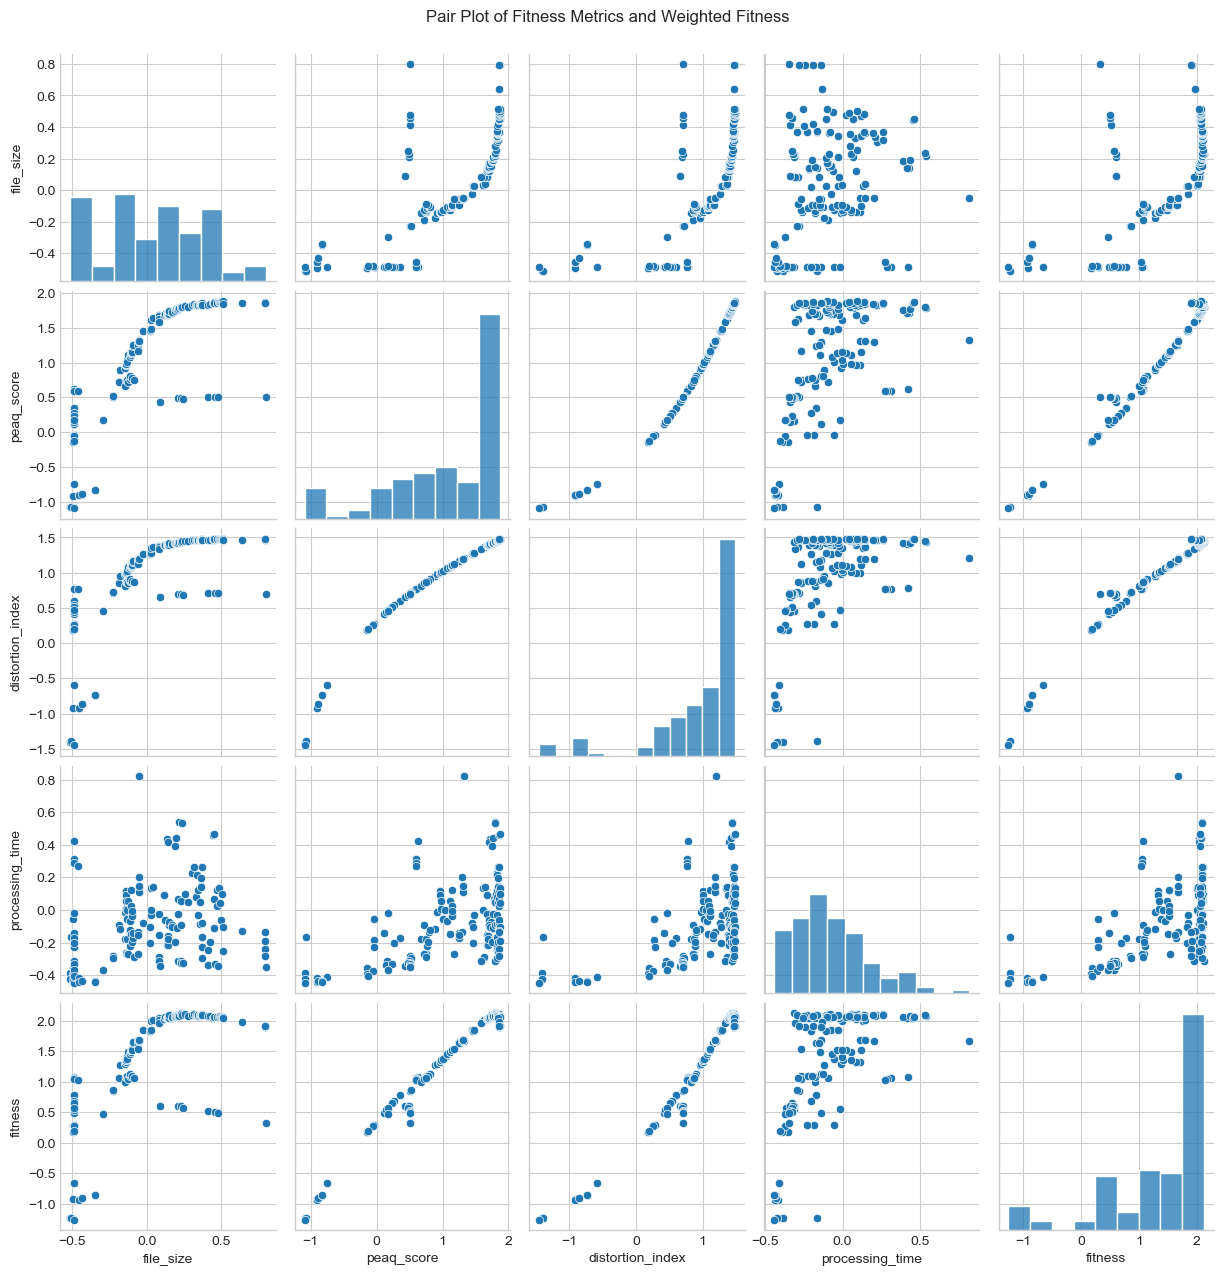

In [34]:
# Select only the numerical fitness columns and fitness for the pair plot
fitness_cols = ['file_size', 'peaq_score', 'distortion_index', 'processing_time', 'fitness']
sns.pairplot(data[fitness_cols])
plt.suptitle('Pair Plot of Fitness Metrics and Weighted Fitness', y=1.02) # Adjust title position
plt.show()

peaq_score


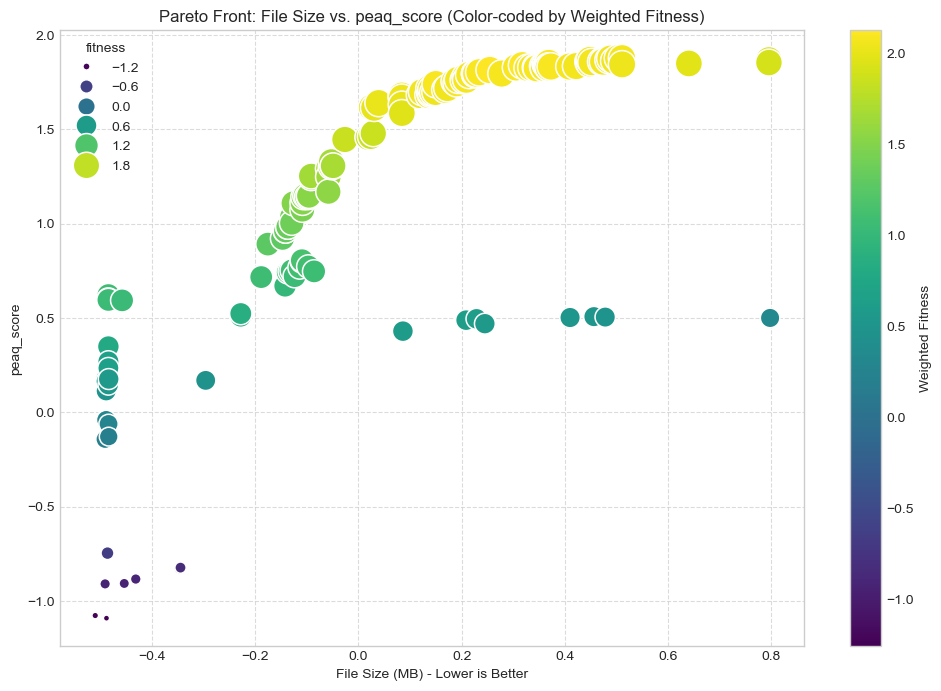

distortion_index


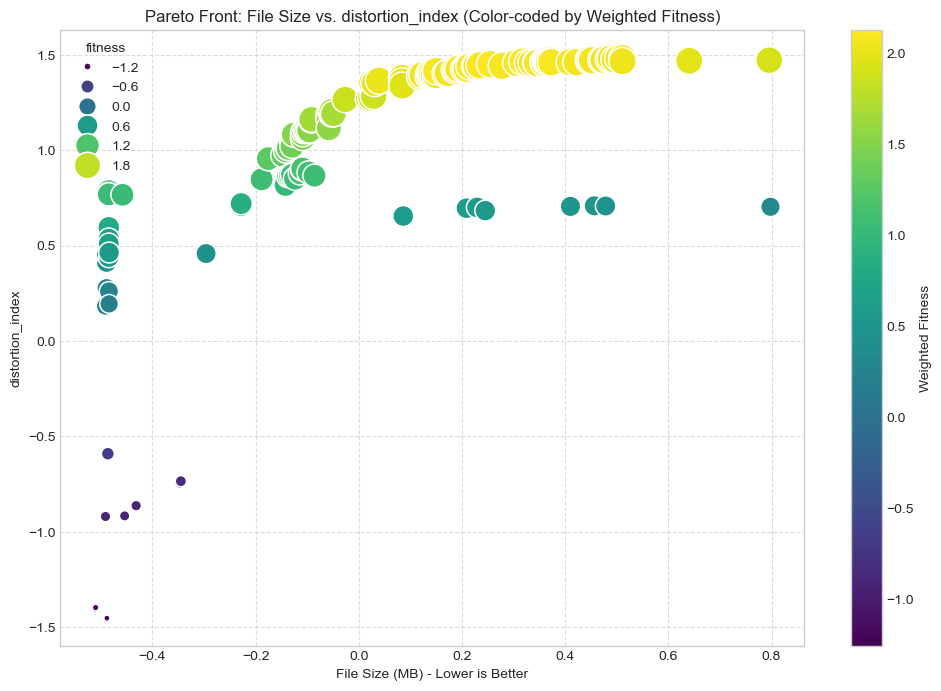

processing_time


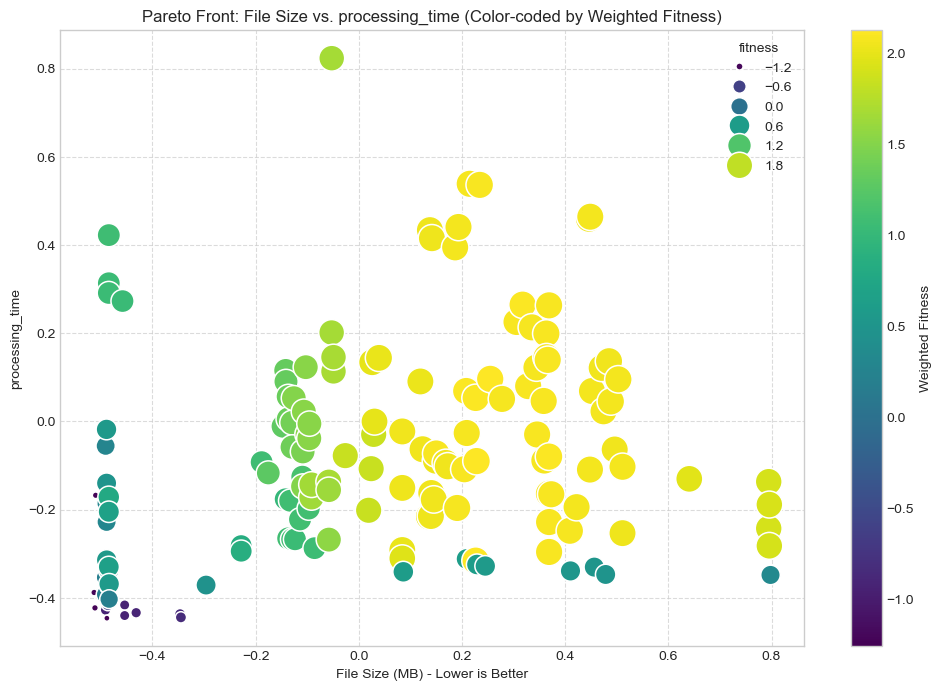

In [35]:
for feature in ['peaq_score','distortion_index','processing_time']:
    print(feature)
    plt.figure(figsize=(12, 8))
    scatter = sns.scatterplot(
        data=data,
        x='file_size', 
        y=feature,
        hue='fitness', # Color points by weighted fitness
        size='fitness', # Size points by weighted fitness (optional, can be removed)
        sizes=(20, 400), # Adjust size range
        palette='viridis', # Choose a colormap
        #legend='full'
    )

    # Reverse x-axis if minimizing file_size makes lower values better
    #plt.gca().invert_xaxis() # Assuming lower file_size is better

    plt.title(f'Pareto Front: File Size vs. {feature} (Color-coded by Weighted Fitness)')
    plt.xlabel('File Size (MB) - Lower is Better')
    plt.ylabel(f'{feature}')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add a color bar
    norm = plt.Normalize(data['fitness'].min(), data['fitness'].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=scatter.axes)
    cbar.set_label('Weighted Fitness')

    plt.show()

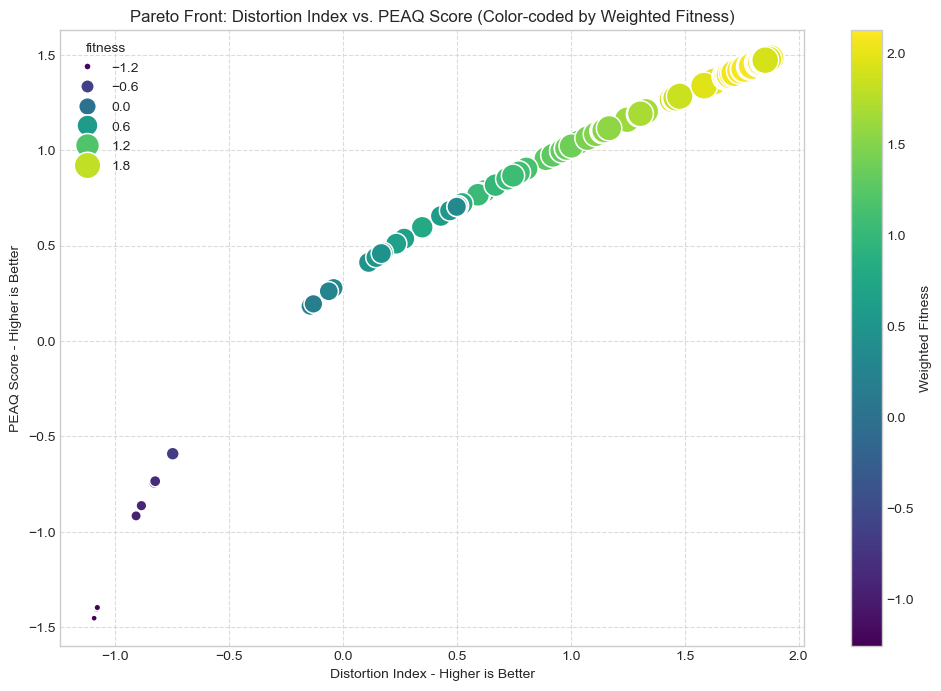

In [36]:
# ['file_size', 'peaq_score','distortion_index','processing_time']
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=data,
    x='peaq_score',
    y='distortion_index',
    hue='fitness', # Color points by weighted fitness
    size='fitness', # Size points by weighted fitness (optional, can be removed)
    sizes=(20, 400), # Adjust size range
    palette='viridis', # Choose a colormap
    #legend='full'
)

# Adjust y-axis if PEAQ score's interpretation implies higher is better
# PEAQ scores are typically negative, closer to 0 or positive is better
# So, no inversion needed, higher up on the y-axis is better.

plt.title('Pareto Front: Distortion Index vs. PEAQ Score (Color-coded by Weighted Fitness)')
plt.xlabel('Distortion Index - Higher is Better')
plt.ylabel('PEAQ Score - Higher is Better')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a color bar
norm = plt.Normalize(data['fitness'].min(), data['fitness'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label('Weighted Fitness')

plt.show()

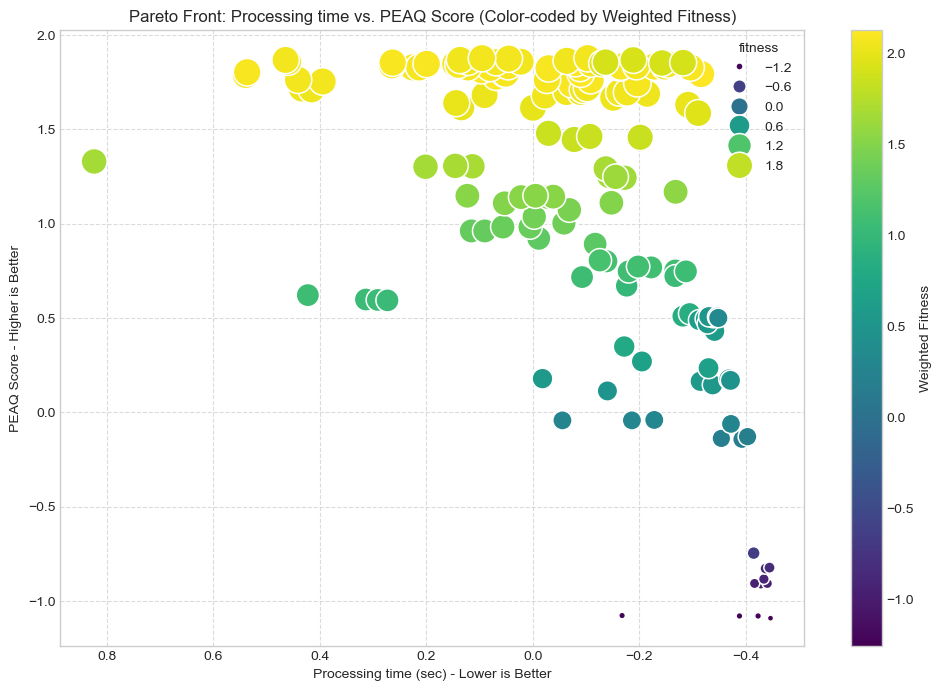

In [37]:
# ['file_size', 'peaq_score','distortion_index','processing_time']
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=data,
    x='processing_time',
    y='peaq_score',
    hue='fitness', # Color points by weighted fitness
    size='fitness', # Size points by weighted fitness (optional, can be removed)
    sizes=(20, 400), # Adjust size range
    palette='viridis', # Choose a colormap
    #legend='full'
)

# Reverse x-axis if minimizing file_size makes lower values better
plt.gca().invert_xaxis() # Assuming lower file_size is better


plt.title('Pareto Front: Processing time vs. PEAQ Score (Color-coded by Weighted Fitness)')
plt.xlabel('Processing time (sec) - Lower is Better')
plt.ylabel('PEAQ Score - Higher is Better')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a color bar
norm = plt.Normalize(data['fitness'].min(), data['fitness'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label('Weighted Fitness')

plt.show()

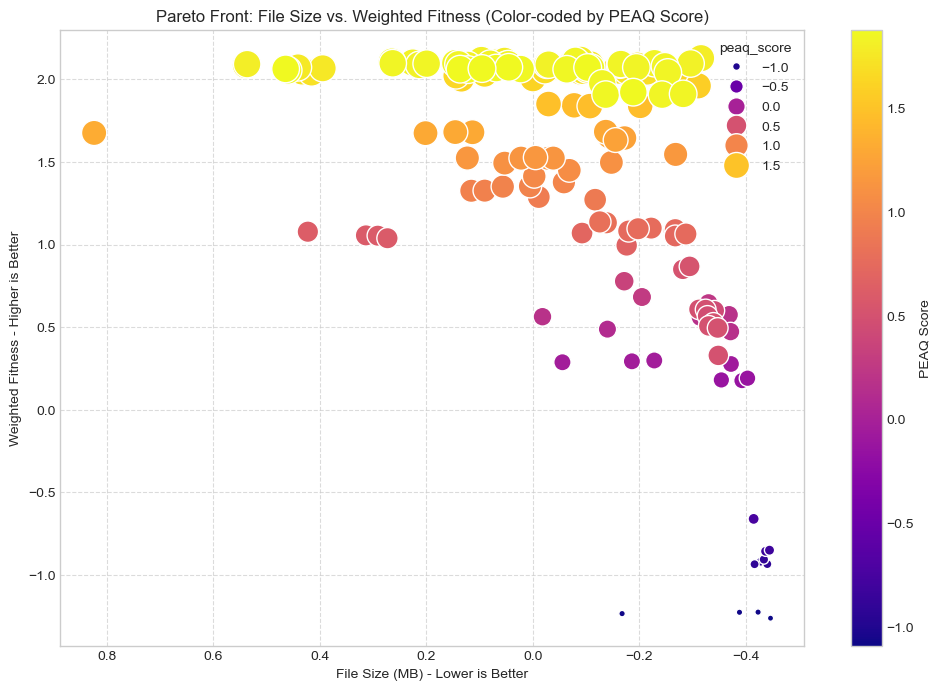

In [38]:
# ['file_size', 'peaq_score','distortion_index','processing_time']
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=data,
    x='processing_time',
    y='fitness',
    hue='peaq_score', # Color points by weighted fitness
    size='peaq_score', # Size points by weighted fitness (optional, can be removed)
    sizes=(20, 400), # Adjust size range
    palette='plasma', # Choose a colormap
    #legend='full'
)

# Reverse x-axis if minimizing file_size makes lower values better
plt.gca().invert_xaxis() # Assuming lower file_size is better

# Adjust y-axis if PEAQ score's interpretation implies higher is better
# PEAQ scores are typically negative, closer to 0 or positive is better
# So, no inversion needed, higher up on the y-axis is better.

plt.title('Pareto Front: File Size vs. Weighted Fitness (Color-coded by PEAQ Score)')
plt.xlabel('File Size (MB) - Lower is Better')
plt.ylabel('Weighted Fitness - Higher is Better')
plt.grid(True, linestyle='--', alpha=0.7)

norm = plt.Normalize(data['peaq_score'].min(), data['peaq_score'].max())
sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label('PEAQ Score')

plt.show()

In [39]:
# import matplotlib.pyplot as plt
# from numpy.random import random
# from mpl_toolkits.mplot3d import Axes3D

# colors=['b', 'c', 'y', 'm', 'r']

# ax = plt.subplot(111, projection='3d')

# ax.plot(random(10), random(10), random(10), 'x', color=colors[0], label='Low Outlier')
# ax.plot(random(10), random(10), random(10), 'o', color=colors[0], label='LoLo')
# ax.plot(random(10), random(10), random(10), 'o', color=colors[1], label='Lo')
# ax.plot(random(10), random(10), random(10), 'o', color=colors[2], label='Average')
# ax.plot(random(10), random(10), random(10), 'o', color=colors[3], label='Hi')
# ax.plot(random(10), random(10), random(10), 'o', color=colors[4], label='HiHi')
# ax.plot(random(10), random(10), random(10), 'x', color=colors[4], label='High Outlier')

# plt.legend(loc='upper left', numpoints=1, ncol=3, fontsize=8, bbox_to_anchor=(0, 0))

# plt.show()

# Best params analysis

In [40]:
threshold = 1.5 # Set threshold for optimal results filtering
df_opt = df[df['fitness'] > threshold]
df_opt

,params,file_size,peaq_score,distortion_index,processing_time,fitness,best
45,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",227.169922,-2.734,-0.863,0.940505,1.840869,False
162,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",227.169922,-2.734,-0.863,1.019689,1.835016,False
265,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",267.627930,-2.617,-0.733,0.423163,2.128162,True
287,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",312.220703,-2.602,-0.717,0.450259,2.095000,False
302,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",227.169922,-2.734,-0.863,1.522220,1.797872,False
...,...,...,...,...,...,...,...
4355,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",356.811523,-2.602,-0.717,0.731469,2.003063,False
4385,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",356.811523,-2.581,-0.694,0.803916,2.053893,False
4386,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",445.995117,-2.590,-0.704,0.787957,1.888641,False
4388,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",365.299805,-2.581,-0.694,0.781351,2.042016,False


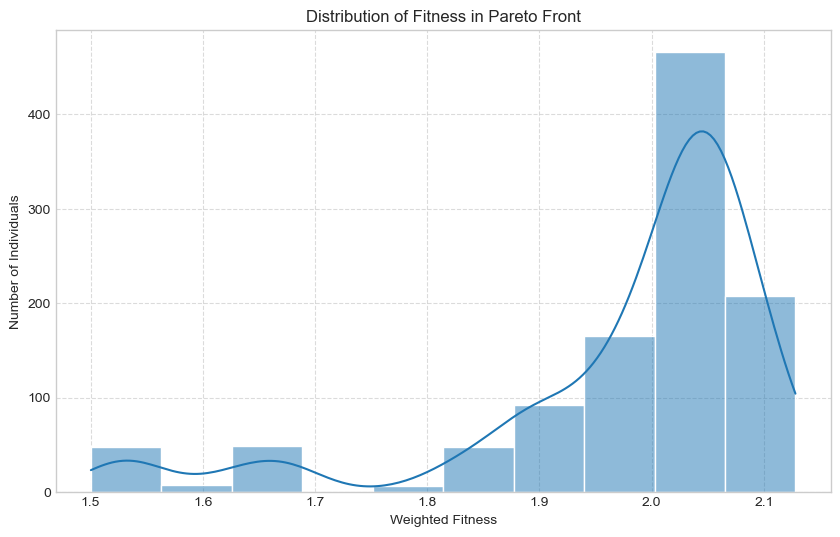

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(df_opt['fitness'], kde=True, bins=10)
plt.title('Distribution of Fitness in Pareto Front')
plt.xlabel('Weighted Fitness')
plt.ylabel('Number of Individuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

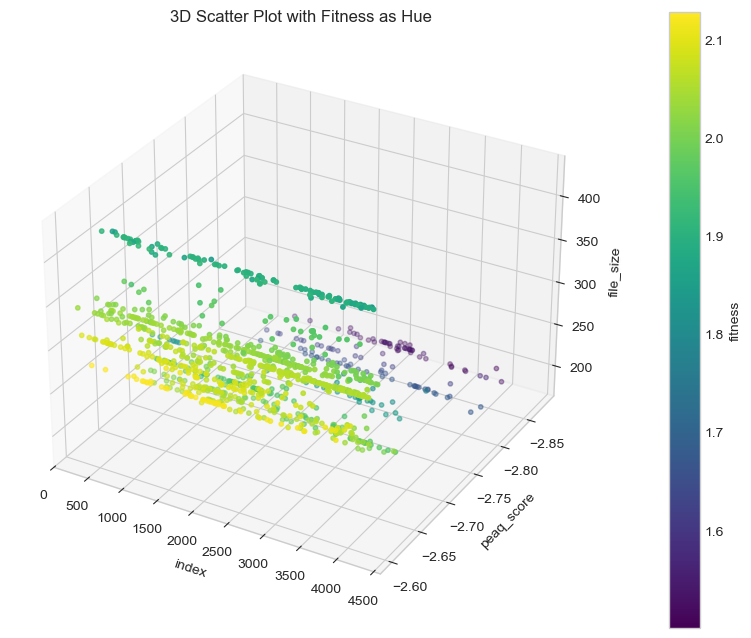

In [42]:
num_points = len(df)

# Set seaborn style for better aesthetics
sns.set_style("whitegrid")

# Create a 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D scatter plot with 'fitness' determining the color
# 'c' parameter is used to map numerical values to colors, and 'cmap' specifies the colormap
scatter = ax.scatter(
    df_opt.index,         # X-axis
    df_opt['peaq_score'], # Y-axis
    df_opt['file_size'],  # Z-axis (using df_optFrame index as requested)
    c=df_opt['fitness'],  # Color based on 'fitness' values
    cmap='viridis',   # Colormap (you can try others like 'plasma', 'magma', 'cividis')
    s=10              # Size of the scatter points
)

# Set labels for each axis
ax.set_xlabel('index')
ax.set_ylabel('peaq_score')
ax.set_zlabel('file_size')

# Set the limits for each axis
ax.set_xlim(0, num_points) # Z-axis limit set to the number of df_opt points
ax.set_ylim(df_opt['peaq_score'].max(), df_opt['peaq_score'].min())
ax.set_zlim(df_opt['file_size'].min(), df_opt['file_size'].max())

# Set the title of the plot
ax.set_title('3D Scatter Plot with Fitness as Hue')

# Add a color bar to explain the 'fitness' color mapping
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('fitness')

# Display the plot
plt.show()

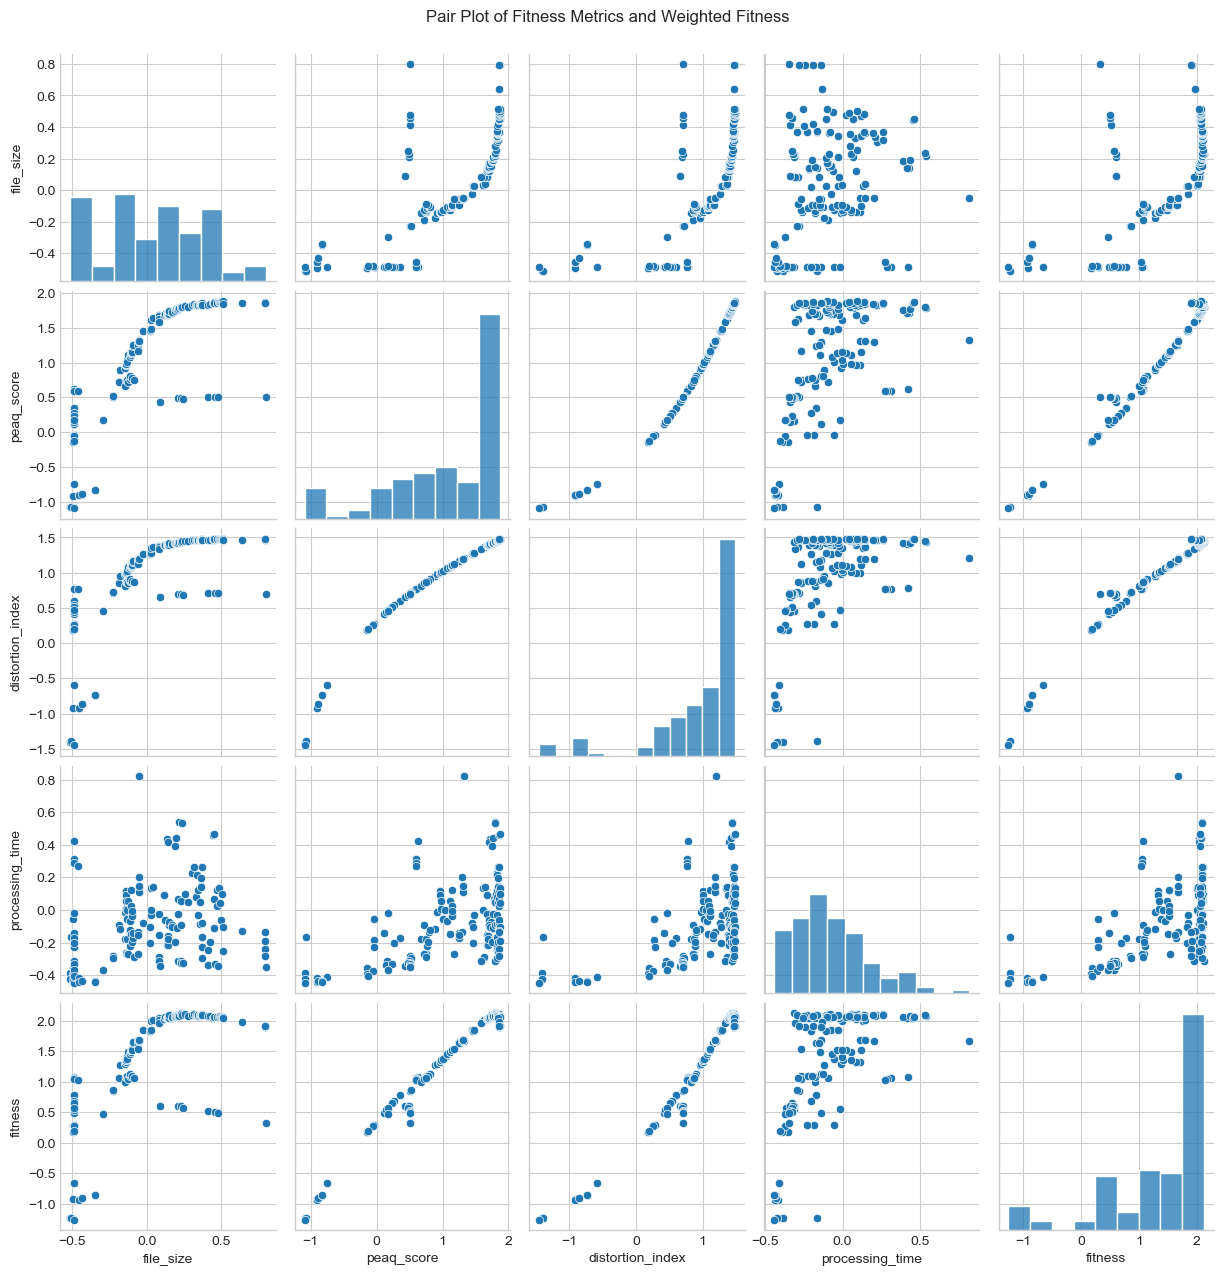

In [43]:
# Select only the numerical fitness columns and fitness for the pair plot
fitness_cols = ['file_size', 'peaq_score', 'distortion_index', 'processing_time', 'fitness']
sns.pairplot(data[fitness_cols])
plt.suptitle('Pair Plot of Fitness Metrics and Weighted Fitness', y=1.02) # Adjust title position
plt.show()

In [44]:
data = df_opt.reset_index()

peaq_score


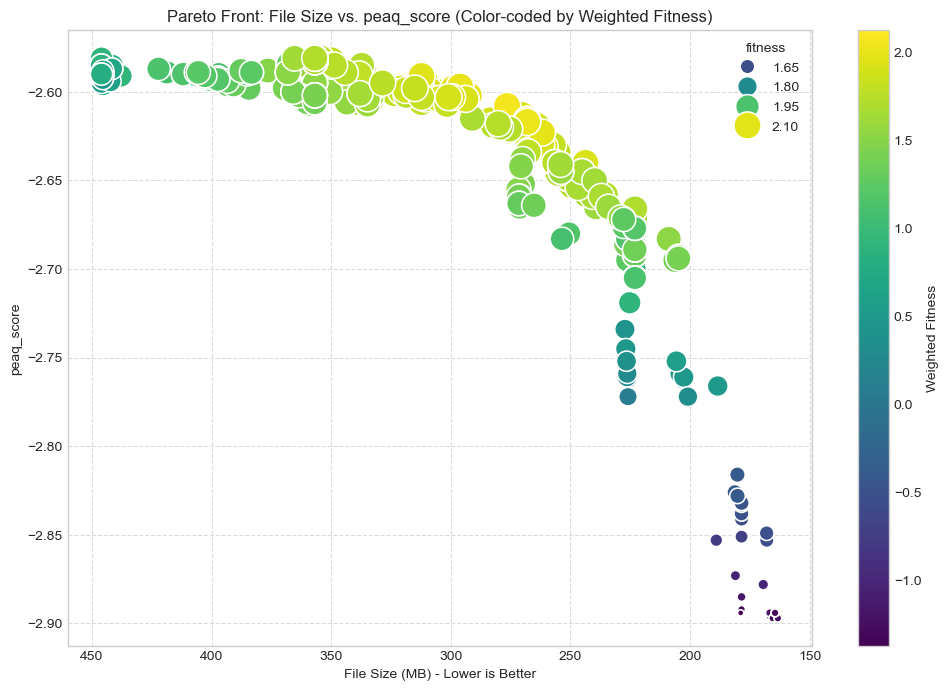

distortion_index


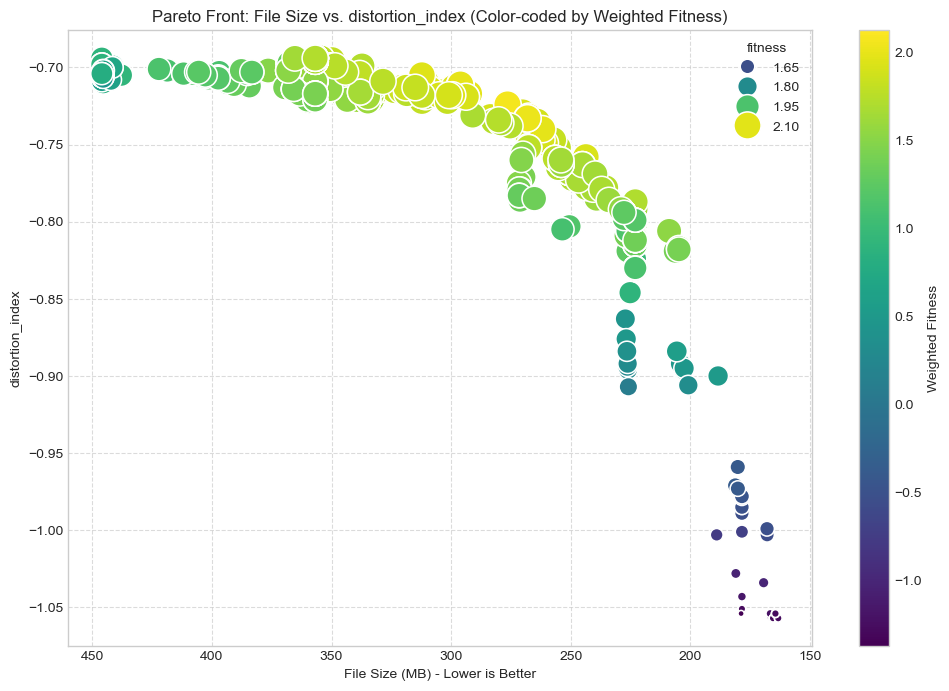

processing_time


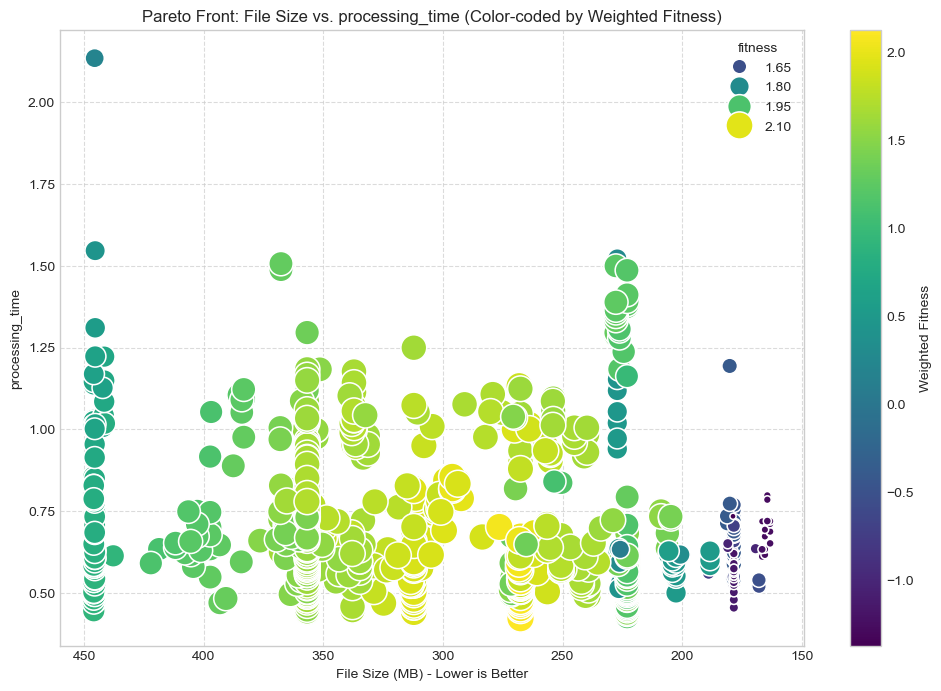

In [45]:
for feature in ['peaq_score','distortion_index','processing_time']:
    print(feature)
    plt.figure(figsize=(12, 8))
    scatter = sns.scatterplot(
        data=data,
        x='file_size', 
        y=feature,
        hue='fitness', # Color points by weighted fitness
        size='fitness', # Size points by weighted fitness (optional, can be removed)
        sizes=(20, 400), # Adjust size range
        palette='viridis', # Choose a colormap
        #legend='full'
    )

    # Reverse x-axis if minimizing file_size makes lower values better
    plt.gca().invert_xaxis() # Assuming lower file_size is better

    plt.title(f'Pareto Front: File Size vs. {feature} (Color-coded by Weighted Fitness)')
    plt.xlabel('File Size (MB) - Lower is Better')
    plt.ylabel(f'{feature}')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add a color bar
    norm = plt.Normalize(df['fitness'].min(), df['fitness'].max())
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=scatter.axes)
    cbar.set_label('Weighted Fitness')

    plt.show()

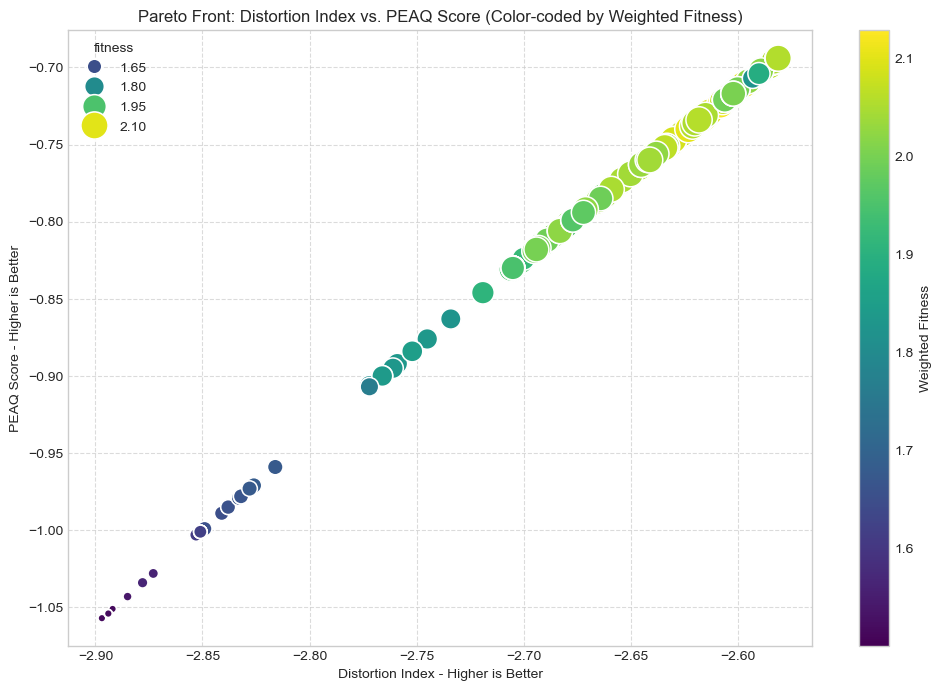

In [46]:
# ['file_size', 'peaq_score','distortion_index','processing_time']
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=data,
    x='peaq_score',
    y='distortion_index',
    hue='fitness', # Color points by weighted fitness
    size='fitness', # Size points by weighted fitness (optional, can be removed)
    sizes=(20, 400), # Adjust size range
    palette='viridis', # Choose a colormap
    #legend='full'
)

# Adjust y-axis if PEAQ score's interpretation implies higher is better
# PEAQ scores are typically negative, closer to 0 or positive is better
# So, no inversion needed, higher up on the y-axis is better.

plt.title('Pareto Front: Distortion Index vs. PEAQ Score (Color-coded by Weighted Fitness)')
plt.xlabel('Distortion Index - Higher is Better')
plt.ylabel('PEAQ Score - Higher is Better')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a color bar
norm = plt.Normalize(data['fitness'].min(), data['fitness'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label('Weighted Fitness')

plt.show()

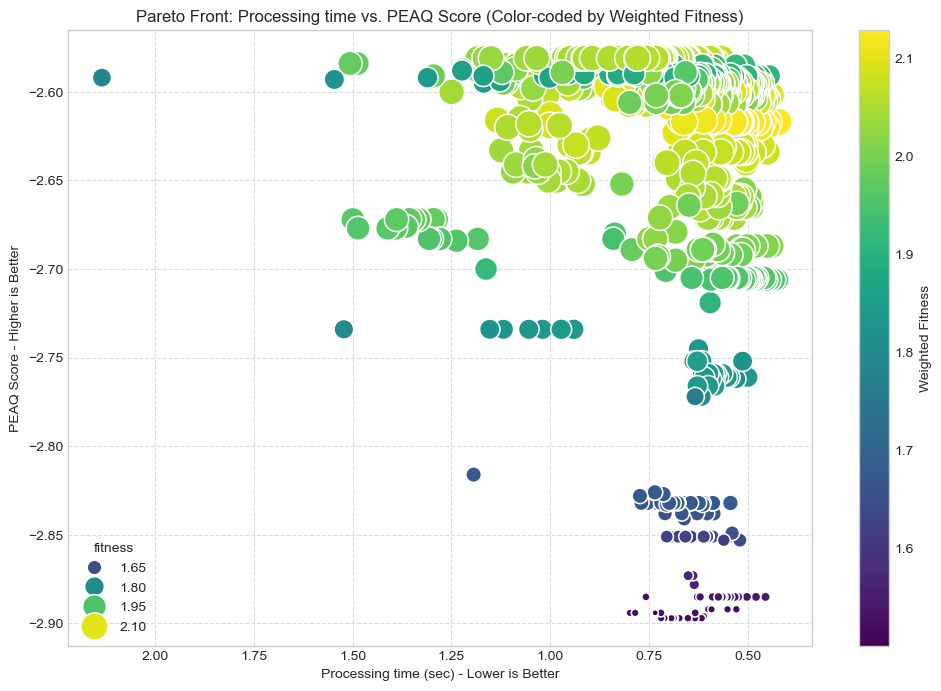

In [47]:
# ['file_size', 'peaq_score','distortion_index','processing_time']
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=data,
    x='processing_time',
    y='peaq_score',
    hue='fitness', # Color points by weighted fitness
    size='fitness', # Size points by weighted fitness (optional, can be removed)
    sizes=(20, 400), # Adjust size range
    palette='viridis', # Choose a colormap
    #legend='full'
)

# Reverse x-axis if minimizing file_size makes lower values better
plt.gca().invert_xaxis() # Assuming lower file_size is better

plt.title('Pareto Front: Processing time vs. PEAQ Score (Color-coded by Weighted Fitness)')
plt.xlabel('Processing time (sec) - Lower is Better')
plt.ylabel('PEAQ Score - Higher is Better')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a color bar
norm = plt.Normalize(data['fitness'].min(), data['fitness'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label('Weighted Fitness')

plt.show()

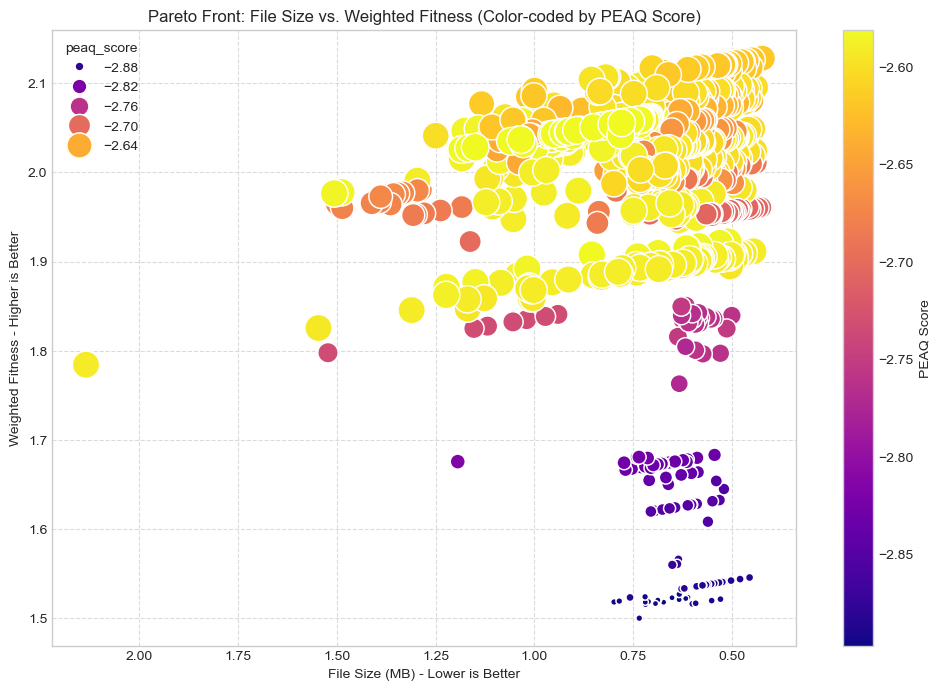

In [48]:
# ['file_size', 'peaq_score','distortion_index','processing_time']
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=data,
    x='processing_time',
    y='fitness',
    hue='peaq_score', # Color points by weighted fitness
    size='peaq_score', # Size points by weighted fitness (optional, can be removed)
    sizes=(20, 400), # Adjust size range
    palette='plasma', # Choose a colormap
    #legend='full'
)

# Reverse x-axis if minimizing file_size makes lower values better
plt.gca().invert_xaxis() # Assuming lower file_size is better

# Adjust y-axis if PEAQ score's interpretation implies higher is better
# PEAQ scores are typically negative, closer to 0 or positive is better
# So, no inversion needed, higher up on the y-axis is better.

plt.title('Pareto Front: File Size vs. Weighted Fitness (Color-coded by PEAQ Score)')
plt.xlabel('File Size (MB) - Lower is Better')
plt.ylabel('Weighted Fitness - Higher is Better')
plt.grid(True, linestyle='--', alpha=0.7)

norm = plt.Normalize(data['peaq_score'].min(), data['peaq_score'].max())
sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=scatter.axes)
cbar.set_label('PEAQ Score')

plt.show()

## Shared params for cluster

In [49]:
import ast
from sklearn.preprocessing import StandardScaler #OneHotEncoder
from sklearn.compose import ColumnTransformer
#from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [50]:
def analyze_params(data):
    # Convert the 'params' column from string to dictionary
    df_params = data.copy()
    df_params['params_dict'] = df_params['params'].apply(ast.literal_eval)

    # Get all unique keys across all dictionaries in the 'params_dict' column
    all_keys = set()
    for params_dict in df_params['params_dict']:
        all_keys.update(params_dict.keys())

    print(f"All unique keys found in 'params' field:\n{sorted(list(all_keys))}\n\n")

    # Analyze value distributions for each key
    for key in sorted(list(all_keys)):
        values_for_key = [d[key] for d in df_params['params_dict'] if key in d]
        
        # Check if all values for a given key are the same
        if len(set(values_for_key)) == 1:
            print(f"🔐 Key '{key}': All values are consistent and equal to {values_for_key[0]}\n")
        else:
            # For non-consistent values, describe the distribution
            print(f"🔑 Key '{key}': Values vary. Some examples: {values_for_key[:5]}")
            # If numerical, provide descriptive statistics
            if all(isinstance(x, (int, float)) for x in values_for_key):
                series = pd.Series(values_for_key)
                print(f"  - Statistics for numerical values:\n{series.describe()}")
            else:
                # For non-numerical or mixed types, just show counts of unique values if there are not too many
                unique_values = pd.Series(values_for_key).value_counts()
                if len(unique_values) < 20: # Arbitrary limit to avoid massive output
                    print(f"  - Value counts:\n{unique_values}\n")
                else:
                    print(f"  - Too many unique values to list all. Top 5:\n{unique_values.head()}\n")

In [77]:
analyze_params(df_opt)

All unique keys found in 'params' field:
['abr', 'aq', 'ar', 'b:a', 'compression_level', 'reservoir', 'sample_fmt']


🔐 Key 'abr': All values are consistent and equal to True

🔑 Key 'aq': Values vary. Some examples: ['4', '4', '4', '3', '3']
  - Value counts:
4    3
3    3
1    1
Name: count, dtype: int64

🔐 Key 'ar': All values are consistent and equal to 44100

🔑 Key 'b:a': Values vary. Some examples: ['156k', '156k', '178k', '236k', '156k']
  - Too many unique values to list all. Top 5:
254k    157
243k    102
293k     51
178k     45
176k     37
Name: count, dtype: int64

🔑 Key 'compression_level': Values vary. Some examples: ['1', '1', '7', '7', '1']
  - Value counts:
7    426
5    270
0    144
9    132
2     46
6     28
8     23
4     12
1     10
Name: count, dtype: int64

🔑 Key 'reservoir': Values vary. Some examples: ['0', '0', '0', '1', '0']
  - Value counts:
1    590
0    501
Name: count, dtype: int64

🔑 Key 'sample_fmt': Values vary. Some examples: ['s16p', 's16p', 's16p', 's

## Clustering

In [92]:
# --- 1. Data Preparation  ---
df_=df.copy()

# Convert 'params' string to dictionary
df_['params_dict'] = df_['params'].apply(ast.literal_eval)

df_.sample()

,level_0,index,params,file_size,peaq_score,distortion_index,processing_time,fitness,best,params_dict
3907,3907,3907,"{'ar': '16000', 'sample_fmt': 's32p', 'compres...",223.707031,-3.765,-2.922,0.597449,-1.179944,False,"{'ar': '16000', 'sample_fmt': 's32p', 'compres..."


In [93]:
# Extract params from dict and convert them into features
for idx, row in df_.iterrows():
    for param in row['params_dict']:
        df_.at[idx, param] = row['params_dict'][param]

In [94]:
# --- 2.  Feature Engineering ---

# Extract features from 'params_dict'
# 'abr' is always True so can be ommited

# Data type conversion
df_['abr'] = df_['abr'].astype(bool)
df_['reservoir'] = df_['reservoir'].astype(bool)
df_['ar'] = df_['ar'].astype(int)
# NaN handling
df_['aq'] = df_['aq'].fillna(-1).astype(int)
df_['compression_level'] = df_['compression_level'].fillna(-1).astype(int)
# 'b:a' also needs string 'k' removal
df_['b:a'] = df_['b:a'].apply(lambda x: int(x.replace('k', '')) if isinstance(x, str) and 'k' in x else x).fillna(-1).astype(int)

# One-hot encode 'sample_fmt' and join to df_
sample_fmt_dummies = pd.get_dummies(df_['sample_fmt'], prefix='sample_fmt')
df_ = pd.concat([df_, sample_fmt_dummies], axis=1)

# Select features for clustering
# # We'll include all numerical columns and the newly extracted ones
#numerical_features = ['file_size', 'peaq_score', 'distortion_index', 'processing_time', 'fitness', 'aq','ar','b:a', 'compression_level']
numerical_features = ['file_size', 'peaq_score', 'distortion_index', 'processing_time', 'aq','ar','b:a', 'compression_level']
#categorical_features = ['best', 'abr', 'reservoir'] + list(sample_fmt_dummies.columns)
categorical_features = ['reservoir'] + list(sample_fmt_dummies.columns)

# # # Combine selected features into a new DataFrame for processing
features_df = df_[numerical_features + categorical_features].copy()
#features_df = df_[numerical_features].copy()

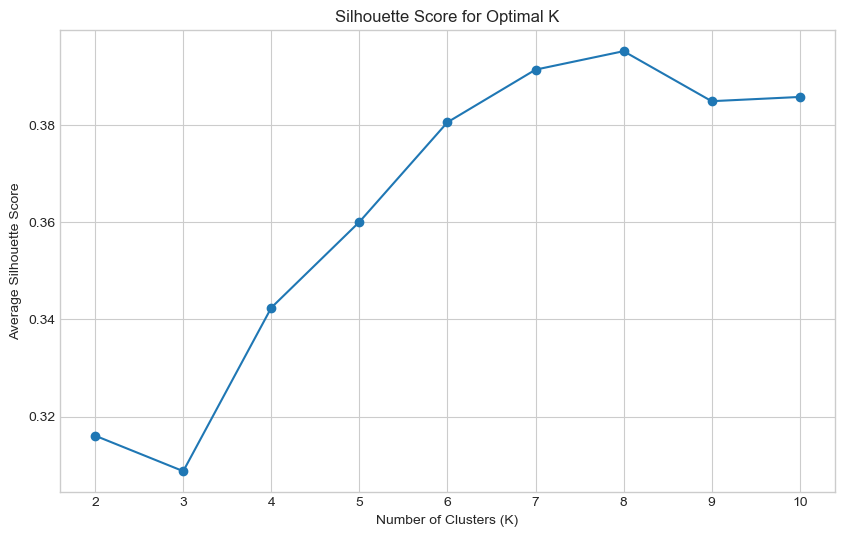


--- Interpreting the Silhouette Plot ---
The optimal K is usually the one that yields the highest average Silhouette Score.
Silhouette scores for K=[2, 3, 4, 5, 6, 7, 8, 9, 10]: [np.float64(0.31607438518252995), np.float64(0.30877412483224836), np.float64(0.34241213153782574), np.float64(0.3600484907260516), np.float64(0.3805551820467541), np.float64(0.3913813763538053), np.float64(0.3951830490187793), np.float64(0.38489441955023196), np.float64(0.3857650390099014)]


In [95]:
# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

# --- Reuse scaled_features from the Elbow Method example ---

# Apply Silhouette Score for a range of K values
silhouette_scores = []
# For Silhouette Score, k must be >= 2
k_range_silhouette = range(2, min(11, scaled_features.shape[0]))

for i in k_range_silhouette:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, cluster_labels)
    silhouette_scores.append(score)

# Plot the Silhouette Score graph
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range_silhouette)
plt.grid(True)
plt.show()

print("\n--- Interpreting the Silhouette Plot ---")
print("The optimal K is usually the one that yields the highest average Silhouette Score.")
print(f"Silhouette scores for K={list(k_range_silhouette)}: {silhouette_scores}")

In [96]:
n_clusters = k_range_silhouette[np.argmax(silhouette_scores)]
print(f"Silhouette score showed that {n_clusters} is the optimal number of clusters.")

Silhouette score showed that 8 is the optimal number of clusters.


In [ ]:
# from sklearn.preprocessing import OneHotEncoder

# # Preprocessing pipeline
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical_features),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
#     ])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical_features)
#     ])

# Apply preprocessing
#processed_features = preprocessor.fit_transform(features_df)
processed_features = features_df
print(f"\nShape of processed features for t-SNE: {processed_features.shape}")

# --- 3. Apply t-SNE ---
# n_components=2 for 2D visualization
# perplexity is a key parameter, often tested in ranges like 5-50
# random_state for reproducibility
tsne = TSNE(n_components=2, perplexity=min(5, processed_features.shape[0] - 1), random_state=42) # Adjust perplexity for small dataset
tsne_results = tsne.fit_transform(processed_features)

df_tsne = pd.DataFrame(data=tsne_results, columns=['tsne_component_1', 'tsne_component_2'])

# --- 4. Apply Clustering (e.g., K-Means) to t-SNE results ---
# In a real scenario, you'd determine the optimal 'k' using methods like Elbow/Silhouette.
# For demonstration, let's assume 3 clusters for this dummy data.
#n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(tsne_results)
df_tsne['cluster'] = clusters

print(f"\nClusters found (k={n_clusters}):")
print(df_tsne['cluster'].value_counts())


Shape of processed features for t-SNE: (4590, 12)

Clusters found (k=8):
cluster
5    791
7    571
2    568
3    558
6    547
4    532
1    514
0    509
Name: count, dtype: int64


In [98]:
# Optional: Add original 'best' column to t-SNE for comparison if relevant
df_tsne['best'] = df['best'].values
df_tsne[df_tsne['best']==True]

,tsne_component_1,tsne_component_2,cluster,best
13,-76.394112,-9.016286,7,True
37,-29.068548,8.832168,5,True
40,110.040779,-7.332079,3,True
47,-54.396591,-39.112804,0,True
89,-69.408615,-7.532784,7,True
...,...,...,...,...
3825,64.512047,5.236199,3,True
3837,57.483006,30.618151,3,True
3956,49.136272,8.722790,3,True
4000,25.472229,-27.753941,5,True


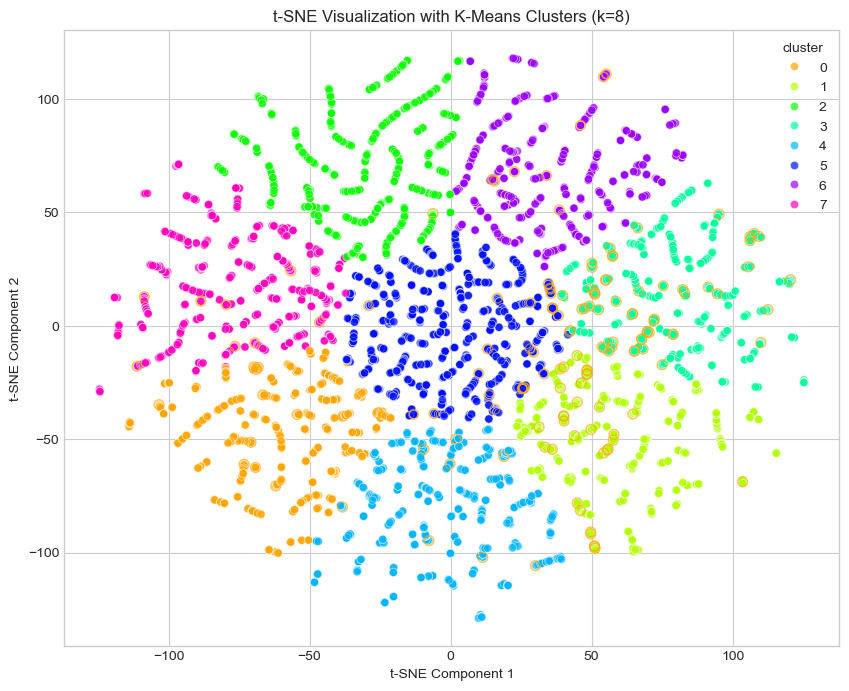

In [99]:
# --- 5. Graph the Clusters ---
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="tsne_component_1", y="tsne_component_2",
    hue="cluster",
    palette=sns.color_palette("hsv", n_clusters), # Use a distinct color palette
    data=df_tsne,
    legend="full",
    alpha=0.7
)

# Overlay original 'best' points as orange circles with no fill
best_points = df_tsne[df_tsne['best']]
plt.scatter(
    best_points['tsne_component_1'],
    best_points['tsne_component_2'],
    facecolors='none',
    edgecolors='orange',
    marker='o',
    s=50,
    linewidths=1,
    alpha=0.65,
    label='Best (original)'
)
plt.title(f't-SNE Visualization with K-Means Clusters (k={n_clusters})')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

In [103]:
df_tsne = df_tsne.reset_index()
df = df.reset_index()

ValueError: cannot insert level_0, already exists

In [ ]:
if df_res is not None:
	merged = pd.merge(df, df_tsne, how='left', on='index')
	# If you want to keep only 'best_x' and rename it to 'best' in merged:
	merged = merged.drop(columns=['best_y'])
	merged = merged.rename(columns={'best_x': 'best'})
	display(merged)
else:
	print("df_res is None. Cannot perform merge.")

,level_0_x,index,params,file_size,peaq_score,distortion_index,processing_time,fitness,best,level_0_y,tsne_component_1,tsne_component_2,cluster
0,0,0,"{'ar': '24000', 'sample_fmt': 'fltp', 'compres...",186.195312,-3.662,-2.501,0.749544,-0.758538,False,0,-32.531879,-47.080063,0
1,1,1,"{'ar': '32000', 'sample_fmt': 's32p', 'compres...",396.640625,-3.173,-1.435,0.706733,0.384444,False,1,-9.001211,-26.330473,5
2,2,2,"{'ar': '22050', 'sample_fmt': 'fltp', 'compres...",75.088867,-3.731,-2.763,0.406703,-0.799325,False,2,-48.614529,-55.875881,0
3,3,3,"{'ar': '24000', 'sample_fmt': 's16p', 'compres...",223.671875,-3.661,-2.498,0.444020,-0.792480,False,3,-36.334198,-14.347516,5
4,4,4,"{'ar': '11025', 'sample_fmt': 'fltp', 'compres...",90.893555,-3.849,-3.437,0.341019,-1.307241,False,4,-76.404816,37.378590,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4585,4585,4585,"{'ar': '32000', 'sample_fmt': 's32p', 'compres...",446.703125,-3.172,-1.435,1.095327,0.278169,False,4585,16.661280,40.615810,6
4586,4586,4586,"{'ar': '32000', 'sample_fmt': 's32p', 'compres...",446.703125,-3.172,-1.435,0.950699,0.288859,False,4586,13.159410,47.665581,6
4587,4587,4587,"{'ar': '32000', 'sample_fmt': 's32p', 'compres...",446.703125,-3.172,-1.435,0.756994,0.303176,False,4587,-39.623081,82.314423,2
4588,4588,4588,"{'ar': '32000', 'sample_fmt': 's32p', 'compres...",446.703125,-3.172,-1.435,0.844874,0.296681,False,4588,-7.873820,71.048691,2


In [105]:
data = merged[merged['best']==True]['cluster']
data = pd.DataFrame(data)

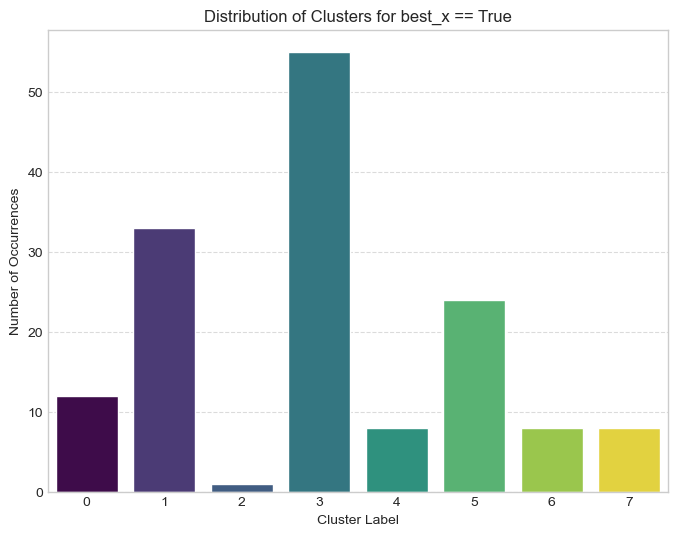

In [106]:
# --- Plot the distribution of 'cluster' for the filtered data ---
plt.figure(figsize=(8, 6))
sns.countplot(x='cluster', data=data, palette='viridis', hue='cluster', legend=False)
plt.title('Distribution of Clusters for best_x == True')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Occurrences')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [107]:
# Calculate the average number of occurrences per cluster in the merged DataFrame
cluster_counts = data['cluster'].value_counts().sort_index()
average_occurrences = cluster_counts.mean()
print(f"Average best individuals per cluster: {average_occurrences:.0f}")

best_clusters = []

for cluster, count in enumerate(cluster_counts):
    if count >= average_occurrences: best_clusters.append(cluster)

print(f"Most succesfull clusters were {best_clusters}.")

Average best individuals per cluster: 19
Most succesfull clusters were [1, 3, 5].


In [115]:
df_best = merged[merged['best']==True].copy()
df_best = df_best.drop(columns=['tsne_component_1','tsne_component_2'])
#df_best = df_best.rename(columns={'best_x': 'best'})
display(df_best)

,level_0_x,index,params,file_size,peaq_score,distortion_index,processing_time,fitness,best,level_0_y,cluster
13,13,13,"{'ar': '12000', 'sample_fmt': 's32p', 'compres...",54.406250,-3.776,-2.975,0.355218,-0.934242,True,13,7
37,37,37,"{'ar': '12000', 'sample_fmt': 's16p', 'compres...",88.578125,-3.740,-2.803,0.336250,-0.849230,True,37,5
40,40,40,"{'ar': '44100', 'sample_fmt': 's32p', 'compres...",103.874023,-3.314,-1.668,0.385774,0.473301,True,40,3
47,47,47,"{'ar': '16000', 'sample_fmt': 'fltp', 'compres...",44.972656,-3.311,-1.663,0.387545,0.575724,True,47,0
89,89,89,"{'ar': '12000', 'sample_fmt': 's16p', 'compres...",54.406250,-3.776,-2.976,0.339045,-0.933362,True,89,7
...,...,...,...,...,...,...,...,...,...,...,...
3825,3825,3825,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",344.143555,-2.589,-0.703,0.718862,2.058915,True,3825,3
3837,3837,3837,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",348.614258,-2.585,-0.699,0.729154,2.061602,True,3837,3
3956,3956,3956,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",299.505859,-2.603,-0.718,0.690953,2.094853,True,3956,3
4000,4000,4000,"{'ar': '44100', 'sample_fmt': 's16p', 'compres...",180.178711,-2.816,-0.959,1.193913,1.675782,True,4000,5


In [122]:
for cluster in best_clusters:
    print("="*100)
    print(f"CLUSTER {cluster} WITH {cluster_counts[cluster]} INDIVIDUALS\n")
    analyze_params(df_best[df_best['cluster']==cluster])
    print("\n\n")

CLUSTER 1 WITH 33 INDIVIDUALS

All unique keys found in 'params' field:
['abr', 'aq', 'ar', 'b:a', 'compression_level', 'reservoir', 'sample_fmt']


🔐 Key 'abr': All values are consistent and equal to True

🔑 Key 'aq': Values vary. Some examples: ['6', '6', '4', '6', '4']
  - Value counts:
6    3
4    2
5    1
3    1
Name: count, dtype: int64

🔐 Key 'ar': All values are consistent and equal to 44100

🔑 Key 'b:a': Values vary. Some examples: ['120k', '121k', '121k', '121k', '121k']
  - Value counts:
121k    5
123k    5
124k    3
120k    2
115k    2
119k    2
114k    2
117k    1
116k    1
122k    1
113k    1
36k     1
Name: count, dtype: int64

🔑 Key 'compression_level': Values vary. Some examples: ['9', '7', '5', '7', '9']
  - Value counts:
7    10
5    10
9     7
4     3
6     2
0     1
Name: count, dtype: int64

🔑 Key 'reservoir': Values vary. Some examples: ['1', '1', '1', '1', '0']
  - Value counts:
1    29
0     4
Name: count, dtype: int64

🔑 Key 'sample_fmt': Values vary. Some exa